# Figures — Patient OTC (consolidated)

Single figure-generation notebook. Stats live in their home notebooks (`wta_formal_stats`, etc.).

**Structure (run top-to-bottom):**
- **Part A — Brain maps:** TFCE clusters + WTA maps + within-cluster composition (from `tfce_wta_figure`)
- **Part B — Peaks & topography:** Fig 2C–H, 2I/J, peak-coord MNI (from `cross-sectional`)
- **Part C — RSA geometry:** distinctiveness, RDM triptychs, Procrustes (from `category_rsa_geometry`)
- **Part D — Sum-selectivity:** ctrl-vs-patient violins with FDR significance (from `cross-sectional`)

Each Part carries its own setup/load so dataframes don't collide across sources.

> Conventions: category order word/face/house/object; ctrl gray, L `#6B8AAD`, R `#E07A8B`; red asterisks, no trend markers.

> **Caveat:** Part A brain cells are `plt.show()`-only (not saved) and depend on `wta_data` built in `voxel_allegiance_xs_liu` — run that notebook's WTA-compute cells first (or the included compute cell) before Part A.


## Master setup

In [21]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
#LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv')
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/liu_exact_replication_v2.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

# Build SUB_CODES from sub_info.csv: code if available, else sub-XXX number
_info_df = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/sub_info.csv')
SUB_CODES = {row['sub']: (row['code'] if pd.notna(row['code']) and row['code'] != '' else row['sub'].replace('sub-', ''))
             for _, row in _info_df.drop_duplicates('sub').iterrows()}

# FDR: 'bh' = Benjamini-Hochberg (liberal); 'by' = Benjamini-Yekutieli (Liu's choice);
# None = disable correction.
FDR_METHOD = 'bh'

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')
print(f'FDR     : {FDR_METHOD}')


LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact
FDR     : bh


# Part A — Brain maps (TFCE + WTA)
From `tfce_wta_figure`. Show-only renders; needs `wta_data` in scope.

In [22]:
# ─── Setup: imports + paths ──────────────────────────────────────────────
import sys
from pathlib import Path
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import plotting

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ─── Choose run + correction method ──────────────────────────────────────
# CORRECTION: 'tfce' uses rand_tfce_corrp_tstat{N}.nii.gz
#             'cluster' uses rand_clustere_corrp_tstat{N}.nii.gz
CORRECTION = 'tfce'   # 'tfce' or 'cluster'

# Reference runs:
#   tfce_votc             — cat-vs-others, no threshold, TFCE-FWE
#   tfce_votc_catbaseline — cat-vs-baseline + Ayzenberg threshold, TFCE-FWE
#   tfce_votc_fdr         — cat-vs-others + thresh 0, TFCE-FWE (FDR-compatible)
#   tfce_votc_cluster     — cat-vs-others + thresh 0, cluster-extent FWE @ t>3.09
TFCE_DIR = Path(processed_dir) / 'group_results' / 'tfce_votc_fdr'

CORRP_PATTERN = {
    'tfce':    'rand_tfce_corrp_tstat{tstat}.nii.gz',
    'cluster': 'rand_clustere_corrp_tstat{tstat}.nii.gz',
}[CORRECTION]

print(f'TFCE outputs: {TFCE_DIR}')
print(f'  exists:     {TFCE_DIR.exists()}')
print(f'  correction: {CORRECTION}  ({CORRP_PATTERN})')

# ─── Quick sanity check — surviving voxels per test ──────────────────────
print(f'\nSurviving voxels per test (FWE p<.05):')
for test_dir in sorted(TFCE_DIR.glob('*_pt_vs_ctrl')):
    for tstat, label in [(1, 'ctrl>pt'), (2, 'pt>ctrl')]:
        f = test_dir / CORRP_PATTERN.format(tstat=tstat)
        if f.exists():
            n_sig = int((nib.load(f).get_fdata() > 0.95).sum())
            if n_sig > 0:
                print(f"  {test_dir.name:<25} {label:>8}: {n_sig:>4} vox")

TFCE outputs: /user_data/csimmon2/sym_pt/group_results/tfce_votc_fdr
  exists:     True
  correction: tfce  (rand_tfce_corrp_tstat{tstat}.nii.gz)

Surviving voxels per test (FWE p<.05):
  house_r_pt_vs_ctrl         ctrl>pt:  480 vox
  object_l_pt_vs_ctrl        ctrl>pt:  437 vox
  word_r_pt_vs_ctrl          pt>ctrl:  663 vox


Group-level patient vs control comparisons of full-VOTC WTA maps using
Liu contrasts and MNI zstats. Tests how voxel allegiance differs between
groups beyond peak displacement and sum-selectivity.

**Sample (cross-sectional):**
- Controls (n≈38): both hemispheres
- OTC patients only (nonOTC excluded), intact hemisphere
- One session per subject (first available post-surgery)

**Analyses (group-level perm tests, 10k permutations, seed 42):**
1. WTA territory % per category × hemisphere
2. Pairwise category neighborhood (boundary preservation)
3. Control-defined territory displacement (where does territory go in patients?)
4. WTA margin distributions per category × hemisphere

**Pipeline alignment:**
- Liu contrasts: cope 1=Face>Object, 2=House>Object, 3=Object>Scramble, −cope 13=Word>Face
- Pre-registered MNI zstats from `13_register_zstats_mni.py`
- WTA threshold z > 2.326
- VOTC mask: Harvard-Oxford labels (MNI 2mm)

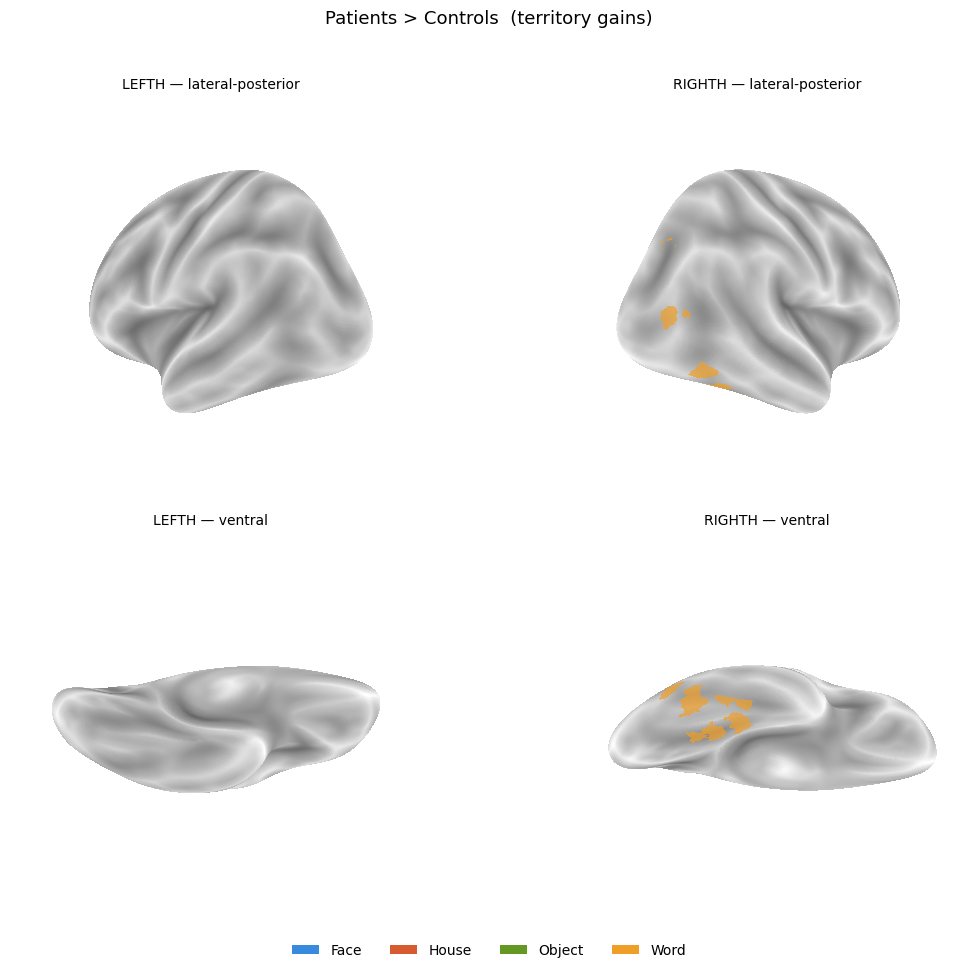

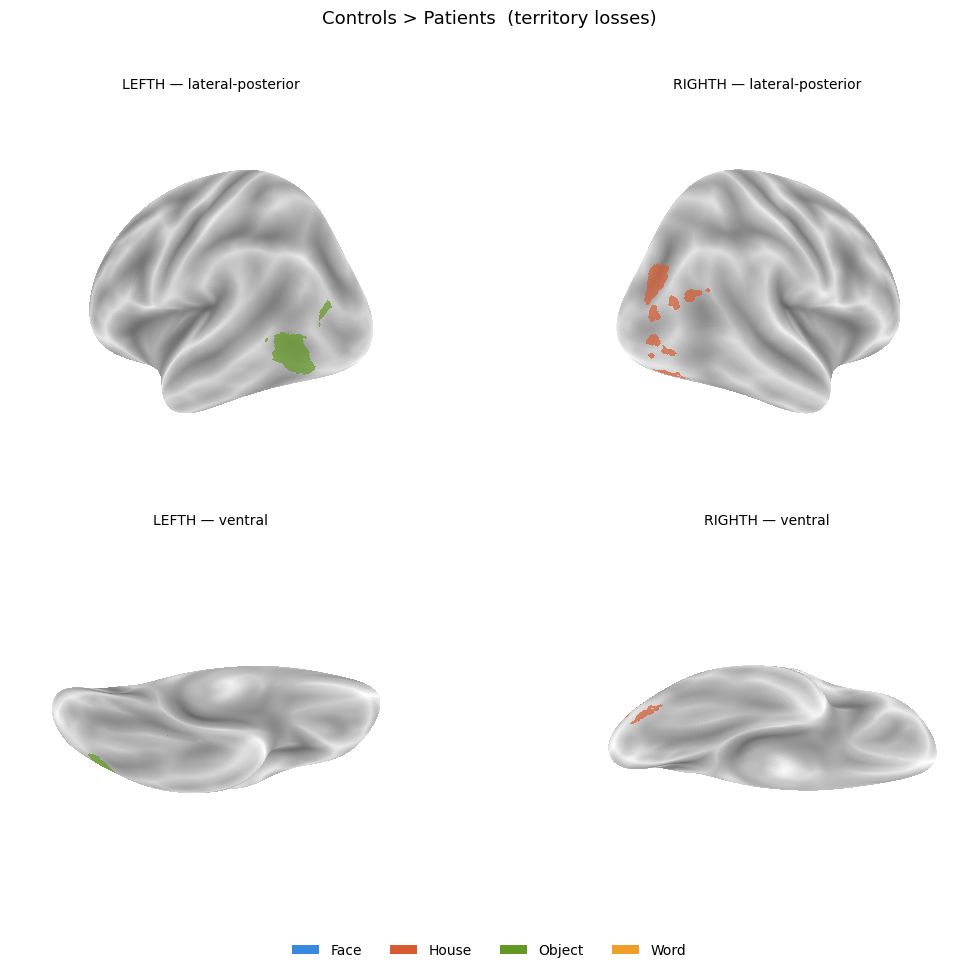

In [23]:
# ─── TFCE clusters: surface views (both hemis, lat-post + ventral) ───────
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from nilearn import datasets as nl_datasets, surface
from nilearn.plotting import plot_surf_roi

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CAT_INT = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

GAINS  = [('face',  'l', 2), ('word',  'r', 2)]
LOSSES = [('object','l', 1), ('house', 'r', 1)]

# Per-hemi view configs: (label, named_view, custom_elev_azim)
# custom_elev_azim is applied via view_init AFTER plot_surf_roi (overrides named view).
# Set to None to use the named view as-is.
VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in ['face','house','object','word']])


def project_clusters_to_surface(clusters, hemi):
    """Combine clusters in one hemisphere into a single surface map (vertex = CAT_INT)."""
    hemi_full = 'left' if hemi == 'l' else 'right'
    out = None
    for cat, h, tstat in clusters:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / f'rand_tfce_corrp_tstat{tstat}.nii.gz'
        vol_img = nib.load(fpath)
        sig = (vol_img.get_fdata() > 0.95).astype(np.float32)
        sig_img = nib.Nifti1Image(sig, vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='line', interpolation='linear',
        )
        if out is None:
            out = np.zeros(surf_vals.shape, dtype=np.int16)
        out[surf_vals > 0.3] = CAT_INT[cat]
    return out if out is not None else np.zeros(10242, dtype=np.int16)


for label, clusters in [('Patients > Controls  (territory gains)', GAINS),
                        ('Controls > Patients  (territory losses)', LOSSES)]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                             subplot_kw={'projection': '3d'})
    fig.suptitle(label, fontsize=13, y=0.98)

    for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
        roi_map = project_clusters_to_surface(clusters, hemi).astype(float)
        for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
            plot_surf_roi(
                fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
                hemi=hemi_full, view=view_named,
                cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
                bg_map=fsaverage[f'sulc_{hemi_full}'],
                bg_on_data=True, darkness=0.6,
                axes=axes[row, col], figure=fig,
            )
            # Override camera angle if custom view requested
            if view_custom is not None:
                elev, azim = view_custom
                axes[row, col].view_init(elev=elev, azim=azim)
            axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

    handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize())
               for c in ['face', 'house', 'object', 'word']]
    fig.legend(handles=handles, loc='lower center', ncol=4,
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.show()

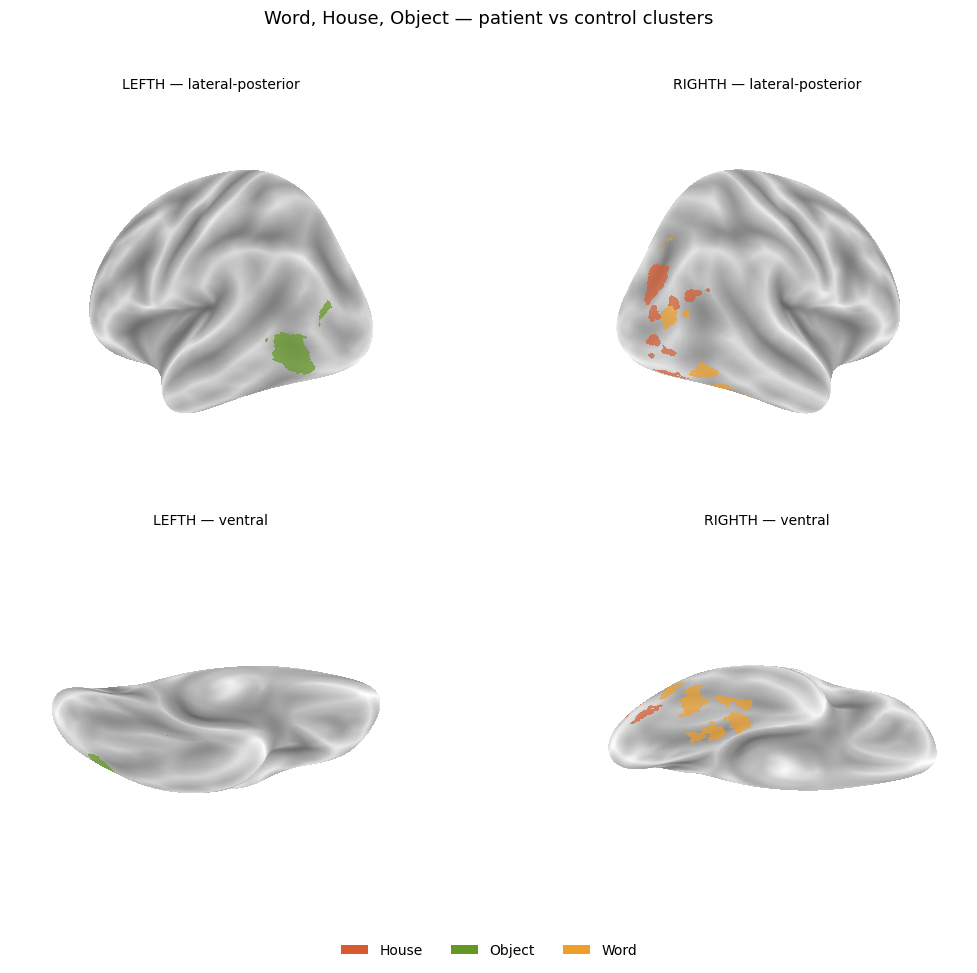

In [24]:
# ─── TFCE clusters: word + house + object on combined surface views ──────
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from nilearn import datasets as nl_datasets, surface
from nilearn.plotting import plot_surf_roi

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CAT_INT = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

# All three clusters in one plot: (category, hemi, tstat)
CLUSTERS = [('word',   'r', 2),   # gain
            ('object', 'l', 1),   # loss
            ('house',  'r', 1)]   # loss

VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in ['face','house','object','word']])

def project_clusters_to_surface(clusters, hemi):
    """Combine clusters in one hemisphere into a single surface map (vertex = CAT_INT)."""
    hemi_full = 'left' if hemi == 'l' else 'right'
    out = None
    for cat, h, tstat in clusters:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / f'rand_tfce_corrp_tstat{tstat}.nii.gz'
        vol_img = nib.load(fpath)
        sig = (vol_img.get_fdata() > 0.95).astype(np.float32)
        sig_img = nib.Nifti1Image(sig, vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='line', interpolation='linear',
        )
        if out is None:
            out = np.zeros(surf_vals.shape, dtype=np.int16)
        out[surf_vals > 0.3] = CAT_INT[cat]
    return out if out is not None else np.zeros(10242, dtype=np.int16)

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                         subplot_kw={'projection': '3d'})
fig.suptitle('Word, House, Object — patient vs control clusters', fontsize=13, y=0.98)

for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
    roi_map = project_clusters_to_surface(CLUSTERS, hemi).astype(float)
    for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
        plot_surf_roi(
            fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
            hemi=hemi_full, view=view_named,
            cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
            bg_map=fsaverage[f'sulc_{hemi_full}'],
            bg_on_data=True, darkness=0.6,
            axes=axes[row, col], figure=fig,
        )
        if view_custom is not None:
            elev, azim = view_custom
            axes[row, col].view_init(elev=elev, azim=azim)
        axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize())
           for c in ['house', 'object', 'word']]
fig.legend(handles=handles, loc='lower center', ncol=3,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

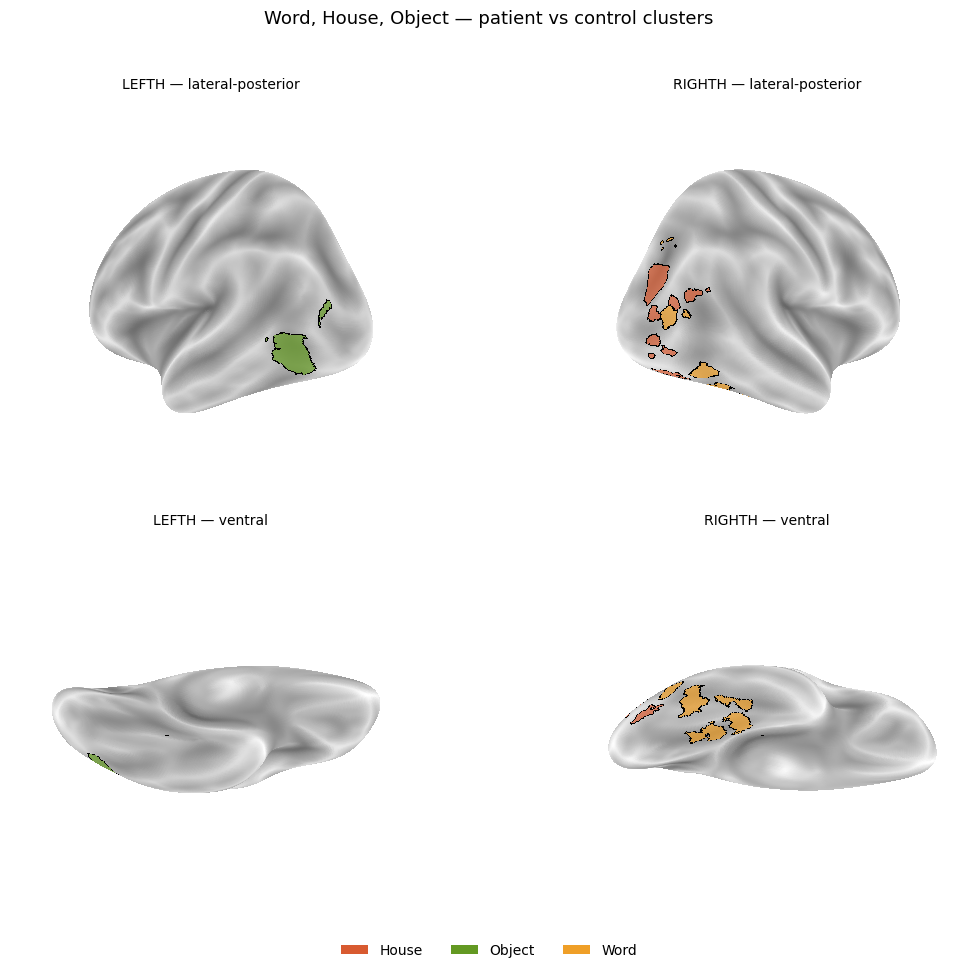

In [25]:
# ─── TFCE clusters: word + house + object with outlines ──────────────────
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from nilearn import datasets as nl_datasets, surface
from nilearn.plotting import plot_surf_roi, plot_surf_contours

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CAT_INT = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

CLUSTERS = [('word',   'r', 2),
            ('object', 'l', 1),
            ('house',  'r', 1)]

VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in ['face','house','object','word']])

def project_clusters_to_surface(clusters, hemi):
    """Combine clusters in one hemisphere into a single surface map (vertex = CAT_INT)."""
    hemi_full = 'left' if hemi == 'l' else 'right'
    out = None
    for cat, h, tstat in clusters:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / f'rand_tfce_corrp_tstat{tstat}.nii.gz'
        vol_img = nib.load(fpath)
        sig = (vol_img.get_fdata() > 0.95).astype(np.float32)
        sig_img = nib.Nifti1Image(sig, vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='line', interpolation='linear',
        )
        if out is None:
            out = np.zeros(surf_vals.shape, dtype=np.int16)
        out[surf_vals > 0.3] = CAT_INT[cat]
    return out if out is not None else np.zeros(10242, dtype=np.int16)

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                         subplot_kw={'projection': '3d'})
fig.suptitle('Word, House, Object — patient vs control clusters', fontsize=13, y=0.98)

for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
    roi_map_int = project_clusters_to_surface(CLUSTERS, hemi)
    roi_map = roi_map_int.astype(float)
    present_labels = [CAT_INT[c] for c in ['house', 'object', 'word']
                      if (roi_map_int == CAT_INT[c]).any()]

    for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
        plot_surf_roi(
            fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
            hemi=hemi_full, view=view_named,
            cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
            bg_map=fsaverage[f'sulc_{hemi_full}'],
            bg_on_data=True, darkness=0.6,
            axes=axes[row, col], figure=fig,
        )
        if present_labels:
            plot_surf_contours(
                fsaverage[f'infl_{hemi_full}'],
                roi_map_int,
                levels=present_labels,
                colors=['black'] * len(present_labels),
                axes=axes[row, col], figure=fig,
                linewidth=1.2,
            )
        if view_custom is not None:
            elev, azim = view_custom
            axes[row, col].view_init(elev=elev, azim=azim)
        axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize())
           for c in ['house', 'object', 'word']]
fig.legend(handles=handles, loc='lower center', ncol=3,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

In [26]:
word_vol  = nib.load(TFCE_DIR / 'word_r_pt_vs_ctrl'  / 'rand_tfce_corrp_tstat2.nii.gz').get_fdata()
house_vol = nib.load(TFCE_DIR / 'house_r_pt_vs_ctrl' / 'rand_tfce_corrp_tstat1.nii.gz').get_fdata()

word_sig  = word_vol  > 0.95
house_sig = house_vol > 0.95

print(f'word_r sig voxels:  {word_sig.sum()}')
print(f'house_r sig voxels: {house_sig.sum()}')
print(f'overlap voxels:     {(word_sig & house_sig).sum()}')

word_r sig voxels:  663
house_r sig voxels: 480
overlap voxels:     6


# WTA

In [27]:
# ─── WTA computation (Liu contrasts, per subject × hemi) ─────────────────
# Recomputes wta_data using SAME VOTC masks as tfce_votc_contrasts.py
# (loaded from TFCE_DIR/votc_{l,r}_mask.nii.gz) to ensure hemi labels
# match TFCE cluster files.

import os
from sym_pt_params import (skip_subs, get_sessions, is_patient,
                            get_sub_info, _load_csv)

CATEGORIES = ['face', 'house', 'object', 'word'] # note liu contrasts are all cat-vs-others, so same winner code (1) for all categories, not actual liu contrasts.
LIU_CONTRASTS = {'face': (6, False), 'house': (7, False),
                 'object': (8, False), 'word': (9, False)}
WTA_THRESHOLD = 2.326
EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

# ── Load VOTC masks (same as TFCE script used) ───────────────────────
_lh_img = nib.load(TFCE_DIR / 'votc_l_mask.nii.gz')
VOTC_MASK_LH = _lh_img.get_fdata() > 0.5
VOTC_MASK_RH = nib.load(TFCE_DIR / 'votc_r_mask.nii.gz').get_fdata() > 0.5
MNI_AFFINE = _lh_img.affine
MNI_SHAPE  = _lh_img.shape
print(f'LH VOTC: {VOTC_MASK_LH.sum():,} | RH VOTC: {VOTC_MASK_RH.sum():,}')

# ── Subject loader ────────────────────────────────────────────────────
def load_subjects_xs():
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs:
            continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        if not sessions or not os.path.exists(os.path.join(processed_dir, sid)):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        group = info.get('group', 'unknown')
        if f"{group}{sc}" in EXTRA_SKIP or sid in EXTRA_SKIP or group == 'nonOTC':
            continue
        post_sessions = [f'{s:02d}' for s in sessions
                         if f'{s:02d}' not in PRE_SURGERY_SESSIONS.get(sid, set())]
        if not post_sessions:
            continue
        subjects[sid] = {
            'session': post_sessions[0], 'group': group,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects

# ── Compute WTA per subject × hemi ────────────────────────────────────
def _load_liu_zstats(sid, ses):
    vols = {}
    for cat, (cope, neg) in LIU_CONTRASTS.items():
        p = os.path.join(processed_dir, sid, f'ses-{ses}', 'derivatives', 'fsl',
                         'loc', 'HighLevel.gfeat', f'cope{cope}.feat', 'stats',
                         'zstat1_mni.nii.gz')
        if not os.path.exists(p):
            return None
        d = nib.load(p).get_fdata()
        vols[cat] = -d if neg else d
    return vols

def _compute_wta(vols, mask):
    z = np.stack([vols[c][mask] for c in CATEGORIES], axis=-1)
    max_z = z.max(axis=-1)
    winner = z.argmax(axis=-1) + 1
    winner[max_z < WTA_THRESHOLD] = 0
    sorted_z = np.sort(z, axis=-1)
    margin = sorted_z[:, -1] - sorted_z[:, -2]
    return winner, margin

subjects = load_subjects_xs()
ctrl_n = sum(1 for i in subjects.values() if i['group'] == 'control')
otc_n  = sum(1 for i in subjects.values() if i['group'] == 'OTC')
print(f'Subjects: {ctrl_n} ctrl + {otc_n} OTC')

wta_data, skipped = {}, []
for sid, info in subjects.items():
    vols = _load_liu_zstats(sid, info['session'])
    if vols is None:
        skipped.append(sid); continue
    hemis = ['l', 'r'] if info['group'] == 'control' else [info['hemi']]
    for h in hemis:
        mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
        winner, margin = _compute_wta(vols, mask)
        wta_data[(sid, h)] = {
            'winner': winner, 'margin': margin,
            'n_voxels': int(mask.sum()),
            'group': info['group'],
            'surgery_side': info.get('surgery_side', 'na'),
        }
print(f'WTA: {len(wta_data)} sub-hemi entries' + (f' | skipped: {skipped}' if skipped else ''))

LH VOTC: 11,340 | RH VOTC: 11,540
Subjects: 38 ctrl + 25 OTC


WTA: 98 sub-hemi entries | skipped: ['sub-098', 'sub-101', 'sub-109']


/tmp/ipykernel_2458475/2470379250.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.97])


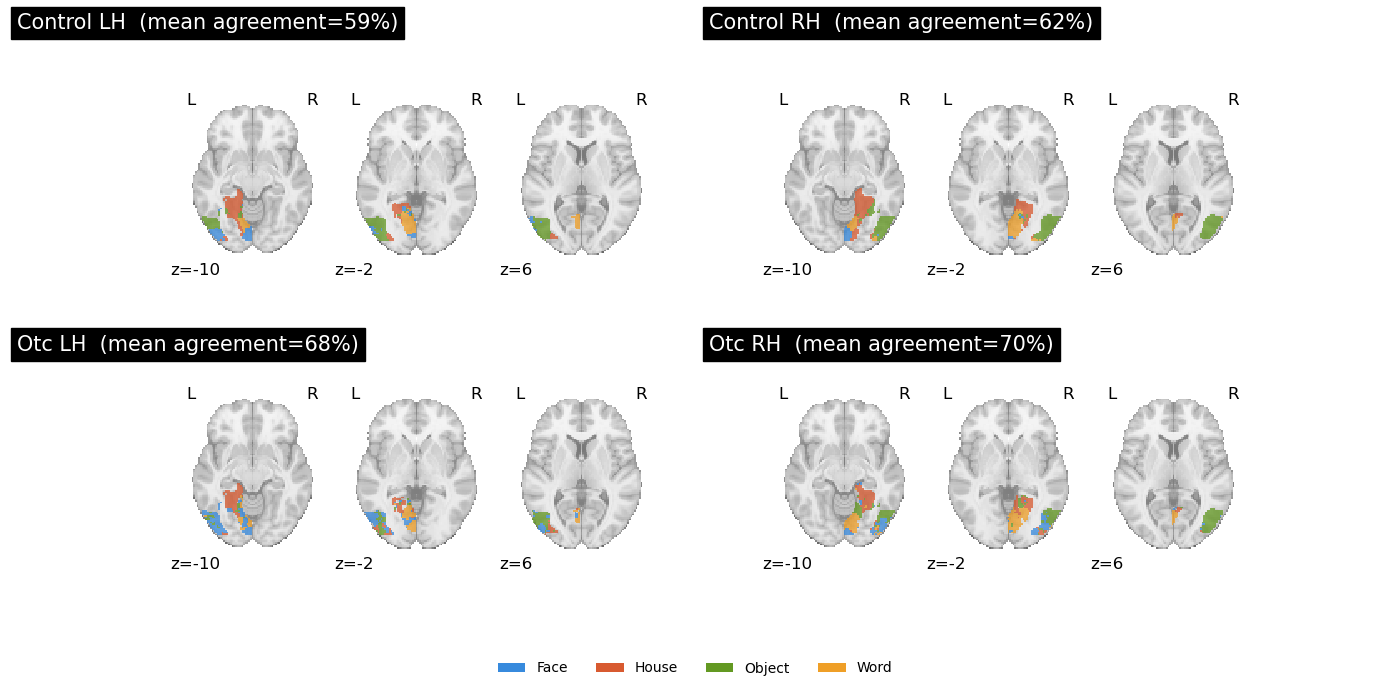

In [28]:
# ─── WTA watercolor: group mode winner + agreement on standard brain ────
# For each voxel in VOTC: most common winning category across subjects (color),
# with opacity scaled by agreement %. Computed per hemi × group.

from matplotlib.colors import ListedColormap, to_rgba
from scipy.stats import mode

assert 'wta_data' in dir(), "Run cells 2, 4, 6 from voxel_allegiance_xs_liu first"
assert 'VOTC_MASK_LH' in dir() and 'MNI_AFFINE' in dir(), \
    "Run cell 4 from voxel_allegiance_xs_liu first (defines masks + affine)"

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

def build_group_wta_3d(group_label, hemi):
    """Per voxel: mode winner across subjects + fraction agreement.
    Returns (winner_3d int, agreement_3d float) shaped like MNI volume."""
    mask = VOTC_MASK_LH if hemi == 'l' else VOTC_MASK_RH
    # Stack winners (n_sub, n_vox) for this group × hemi
    stacked = np.stack([d['winner'] for (sid, h), d in wta_data.items()
                        if h == hemi and d['group'] == group_label])
    # Per-voxel mode (1-4) and agreement (frac winning category)
    mode_vals = np.zeros(stacked.shape[1], dtype=np.int16)
    agree     = np.zeros(stacked.shape[1], dtype=np.float32)
    for v in range(stacked.shape[1]):
        col = stacked[:, v]
        col_sel = col[col > 0]
        if len(col_sel) == 0:
            continue
        vals, counts = np.unique(col_sel, return_counts=True)
        top = np.argmax(counts)
        mode_vals[v] = vals[top]
        agree[v] = counts[top] / len(col_sel)
    # Project back to 3D
    out_winner = np.zeros(mask.shape, dtype=np.int16); out_winner[mask] = mode_vals
    out_agree  = np.zeros(mask.shape, dtype=np.float32); out_agree[mask] = agree
    return out_winner, out_agree

# Build RGBA volume: color from winner, alpha from agreement
def make_rgba_volume(winner, agree):
    rgba = np.zeros(winner.shape + (4,), dtype=np.float32)
    for i, cat in enumerate(CATEGORIES, start=1):
        r, g, b, _ = to_rgba(CAT_COLORS[cat])
        sel = winner == i
        rgba[sel, 0] = r; rgba[sel, 1] = g; rgba[sel, 2] = b
        rgba[sel, 3] = agree[sel]
    return rgba

# Build categorical NIfTI per group×hemi (just for nilearn plot_roi)
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
cat_cmap = ListedColormap([CAT_COLORS[c] for c in CATEGORIES])

for col, (h, hlabel) in enumerate([('l', 'LH'), ('r', 'RH')]):
    for row, grp in enumerate(['control', 'OTC']):
        winner, agree = build_group_wta_3d(grp, h)
        # alpha as fade is hard with plot_roi; use winner as ROI map at fixed alpha
        # and overlay text giving agreement summary
        roi_img = nib.Nifti1Image(winner.astype(np.int16), MNI_AFFINE)
        cut_z = -10 if h == 'l' else -10  # ventral slice
        plotting.plot_roi(
            roi_img, cmap=cat_cmap, alpha=0.75,
            vmin=0.5, vmax=4.5,
            display_mode='z', cut_coords=[cut_z, -2, 6],
            axes=axes[row, col],
            title=f'{grp.capitalize()} {hlabel}  (mean agreement={agree[winner>0].mean():.0%})',
            annotate=True, draw_cross=False,
        )

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES]
fig.legend(handles=handles, ncol=4, frameon=False, fontsize=10,
           loc='lower center', bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

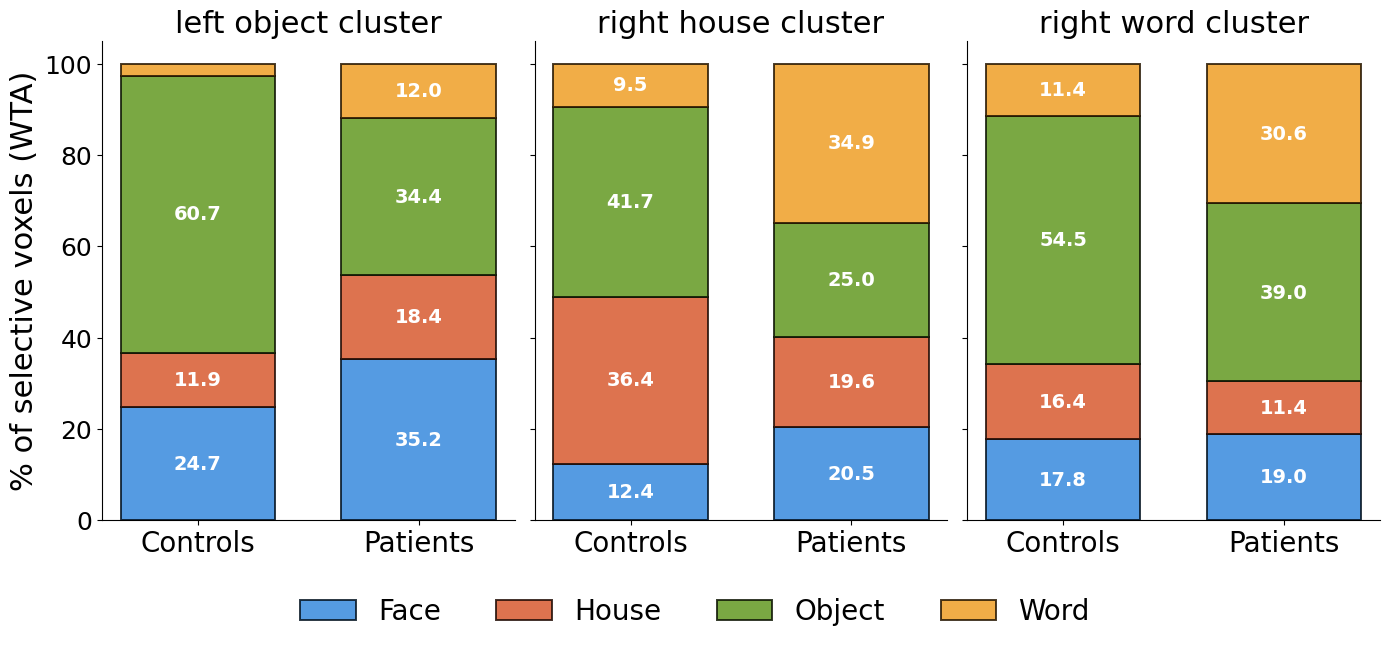

In [29]:
# ─── WTA composition bars (Liu-style, per cluster) ──────────────────────
# Composition normalized to selective voxels only.
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import colorsys

# ===== TRANSPARENCY / OUTLINE CONTROLS =====
BAR_ALPHA      = 0.85    # bar fill transparency (0=invisible, 1=opaque)
EDGE_LINEWIDTH = 1.4     # outline thickness
DARKEN_FACTOR  = 0.15    # outline darkness (lower = darker)
# ===========================================

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

CLUSTERS = [
    ('object', 'l', 1, 'left object cluster'),
    ('house',  'r', 1, 'right house cluster'),
    ('word',   'r', 2, 'right word cluster'),
]

def darken(hex_color, factor=DARKEN_FACTOR):
    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(hex_color))
    return colorsys.hls_to_rgb(h, l * factor, s)


def composition_at_mask(group_label, hemi, cluster_3d_mask, hemi_3d_mask):
    """Returns dict {cat: per_subject_pct_array} normalized to selective voxels."""
    cluster_in_hemi = cluster_3d_mask[hemi_3d_mask]
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        if len(d['winner']) != len(cluster_in_hemi):
            continue
        w = d['winner'][cluster_in_hemi]
        n = (w > 0).sum()
        for i, cat in enumerate(CATEGORIES, start=1):
            per_cat[cat].append(100 * (w == i).sum() / n if n else np.nan)
    return {c: np.array(v) for c, v in per_cat.items()}


fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), sharey=True)
for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTERS):
    cluster_3d = nib.load(TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl' /
                          f'rand_tfce_corrp_tstat{tstat}.nii.gz').get_fdata() > 0.95
    hemi_3d    = nib.load(TFCE_DIR / f'votc_{hemi}_mask.nii.gz').get_fdata() > 0.5

    ctrl_comp = composition_at_mask('control', hemi, cluster_3d, hemi_3d)
    pt_comp   = composition_at_mask('OTC',     hemi, cluster_3d, hemi_3d)

    for xi, comp in zip([0, 1], [ctrl_comp, pt_comp]):
        bottom = 0
        for c in CATEGORIES:
            h = np.nanmean(comp[c])
            ax.bar(xi, h, bottom=bottom, width=0.7,
                   facecolor=CAT_COLORS[c], alpha=BAR_ALPHA,
                   edgecolor=darken(CAT_COLORS[c]), linewidth=EDGE_LINEWIDTH)
            if h >= 3:
                ax.text(xi, bottom + h/2, f'{h:.1f}', ha='center', va='center',
                        fontsize=14, color='white', fontweight='bold')
            bottom += h

    ax.set_xticks([0, 1]); ax.set_xticklabels(['Controls', 'Patients'], fontsize=20)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylim(0, 105); ax.set_title(title, fontsize=22)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

axes[0].set_ylabel('% of selective voxels (WTA)', fontsize=22)

handles = [Patch(facecolor=CAT_COLORS[c], alpha=BAR_ALPHA,
                 edgecolor=darken(CAT_COLORS[c]), linewidth=EDGE_LINEWIDTH,
                 label=c.capitalize()) for c in CATEGORIES]
fig.legend(handles=handles, ncol=4, frameon=False, fontsize=20,
           loc='lower center', bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.show()

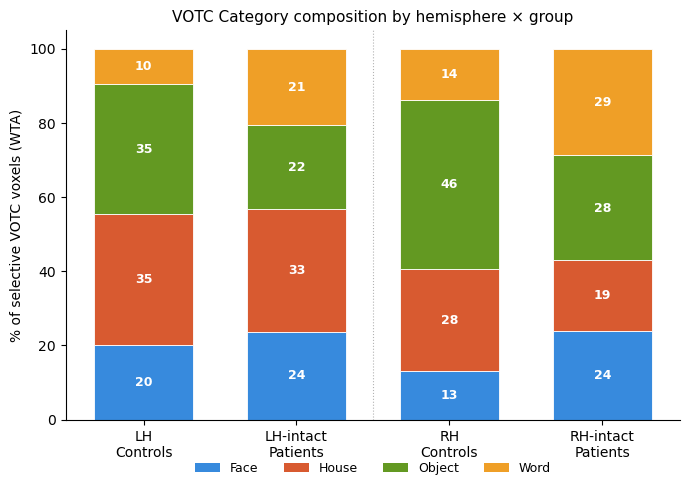


condition                     face     house    object      word
LH Controls                  20.2%     35.3%     34.8%      9.7%
LH-intact Patients           23.7%     33.1%     22.4%     20.7%
RH Controls                  13.1%     27.6%     45.6%     13.8%
RH-intact Patients           24.0%     19.0%     28.1%     28.8%


In [30]:
# ─── Total VOTC composition: stacked bars by hemi × group ────────────────
from matplotlib.patches import Patch

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}

def composition(group_label, hemi):
    """Per-subject % of selective VOTC voxels per category. Returns dict."""
    per_cat = {c: [] for c in CATEGORIES}
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        w = d['winner']
        n = (w > 0).sum()
        for i, c in enumerate(CATEGORIES, start=1):
            per_cat[c].append(100 * (w == i).sum() / n if n else np.nan)
    return per_cat

CONDITIONS = [
    ('control', 'l', 'LH\nControls'),
    ('OTC',     'l', 'LH-intact\nPatients'),
    ('control', 'r', 'RH\nControls'),
    ('OTC',     'r', 'RH-intact\nPatients'),
]

fig, ax = plt.subplots(figsize=(7, 5))
for i, (grp, hemi, label) in enumerate(CONDITIONS):
    comp = composition(grp, hemi)
    bottom = 0
    for c in CATEGORIES:
        mean_pct = np.nanmean(comp[c])
        sem_pct  = np.nanstd(comp[c], ddof=1) / np.sqrt(len(comp[c]))
        ax.bar(i, mean_pct, bottom=bottom, width=0.65, color=CAT_COLORS[c],
               edgecolor='white', linewidth=0.6)
        if mean_pct >= 5:
            ax.text(i, bottom + mean_pct/2, f'{mean_pct:.0f}',
                    ha='center', va='center', fontsize=9, color='white',
                    fontweight='bold')
        bottom += mean_pct

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([c[2] for c in CONDITIONS], fontsize=10)
ax.set_ylabel('% of selective VOTC voxels (WTA)', fontsize=10)
ax.set_ylim(0, 105)
ax.set_title('VOTC Category composition by hemisphere × group', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Visual divider between LH and RH groups
ax.axvline(1.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in CATEGORIES]
ax.legend(handles=handles, ncol=4, frameon=False, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

# Print numerical summary
print(f"\n{'condition':<24} " + ' '.join(f'{c:>9}' for c in CATEGORIES))
for grp, hemi, label in CONDITIONS:
    comp = composition(grp, hemi)
    means = [np.nanmean(comp[c]) for c in CATEGORIES]
    label_flat = label.replace('\n', ' ')
    print(f"{label_flat:<24} " + ' '.join(f'{m:>8.1f}%' for m in means))

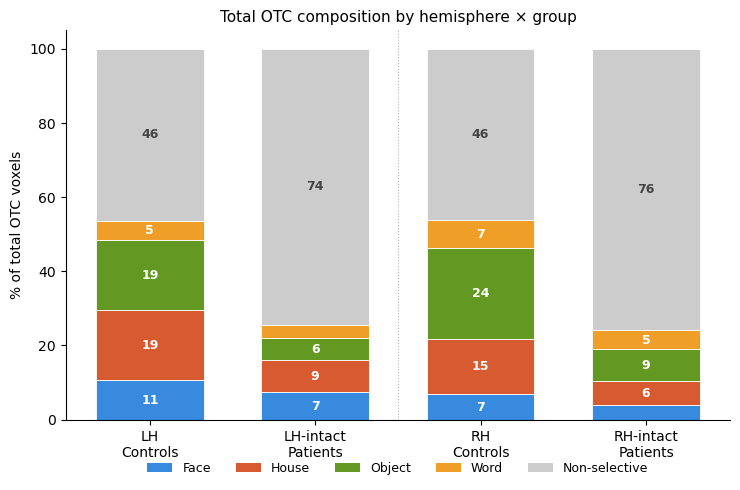


condition                       face       house      object        word non-selective
LH Controls                    10.6%       18.9%       19.0%        5.2%       46.4%
LH-intact Patients              7.4%        8.6%        5.9%        3.6%       74.4%
RH Controls                     6.9%       14.9%       24.4%        7.5%       46.3%
RH-intact Patients              4.0%        6.3%        8.7%        5.1%       75.9%


In [31]:
# ─── Total OTC composition with non-selective: hemi × group ─────────────
from matplotlib.patches import Patch

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
NONSEL_COLOR = '#cccccc'

def composition_full(group_label, hemi):
    """% of ALL OTC voxels per category, including non-selective."""
    per_cat = {c: [] for c in CATEGORIES}
    nonsel = []
    for (sid, h), d in wta_data.items():
        if h != hemi or d['group'] != group_label:
            continue
        w = d['winner']
        n_total = len(w)
        for i, c in enumerate(CATEGORIES, start=1):
            per_cat[c].append(100 * (w == i).sum() / n_total)
        nonsel.append(100 * (w == 0).sum() / n_total)
    per_cat['non-selective'] = nonsel
    return per_cat

CONDITIONS = [
    ('control', 'l', 'LH\nControls'),
    ('OTC',     'l', 'LH-intact\nPatients'),
    ('control', 'r', 'RH\nControls'),
    ('OTC',     'r', 'RH-intact\nPatients'),
]
STACK_ORDER = CATEGORIES + ['non-selective']
STACK_COLORS = {**CAT_COLORS, 'non-selective': NONSEL_COLOR}

fig, ax = plt.subplots(figsize=(7.5, 5))
for i, (grp, hemi, label) in enumerate(CONDITIONS):
    comp = composition_full(grp, hemi)
    bottom = 0
    for c in STACK_ORDER:
        mean_pct = np.nanmean(comp[c])
        ax.bar(i, mean_pct, bottom=bottom, width=0.65, color=STACK_COLORS[c],
               edgecolor='white', linewidth=0.6)
        if mean_pct >= 5:
            text_color = '#444' if c == 'non-selective' else 'white'
            ax.text(i, bottom + mean_pct/2, f'{mean_pct:.0f}',
                    ha='center', va='center', fontsize=9, color=text_color,
                    fontweight='bold')
        bottom += mean_pct

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([c[2] for c in CONDITIONS], fontsize=10)
ax.set_ylabel('% of total OTC voxels', fontsize=10)
ax.set_ylim(0, 105)
ax.set_title('Total OTC composition by hemisphere × group', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.axvline(1.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

handles = [Patch(facecolor=STACK_COLORS[c],
                 label=c.capitalize() if c != 'non-selective' else 'Non-selective')
           for c in STACK_ORDER]
ax.legend(handles=handles, ncol=5, frameon=False, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'condition':<24} " + ' '.join(f'{c:>11}' for c in STACK_ORDER))
for grp, hemi, label in CONDITIONS:
    comp = composition_full(grp, hemi)
    means = [np.nanmean(comp[c]) for c in STACK_ORDER]
    label_flat = label.replace('\n', ' ')
    print(f"{label_flat:<24} " + ' '.join(f'{m:>10.1f}%' for m in means))

# Crawford 

Face-winning voxels per subject (WTA, threshold z>2.326):
group       hemi   n  mean_n_face  sd_n_face              mean_centroid_xyz
--------------------------------------------------------------------------------
control        L  38       1198.6      792.0   (  -37,   -63,    -1)
OTC            L  11        842.5      967.8   (  -34,   -61,    -5)
control        R  38        795.1      504.7   (   37,   -62,    -2)
OTC            R  11        465.8      375.7   (   31,   -62,    12)

Per-patient face-winner detail:
sid           intact  n_face                mni_xyz  extent_mm
sub-004            L      58       ( -49, -67,   4)       92.1
sub-005            L     782       ( -36, -62, -17)      123.7
sub-008            L    1709       ( -33, -70,   5)      112.6
sub-010            R     222       (  15, -77,   6)       97.0
sub-021            R     110       (   3, -76,  -2)       40.6
sub-039            L     748       ( -35, -68,   7)      147.8
sub-044            R    1051       

/tmp/ipykernel_2458475/1432292130.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


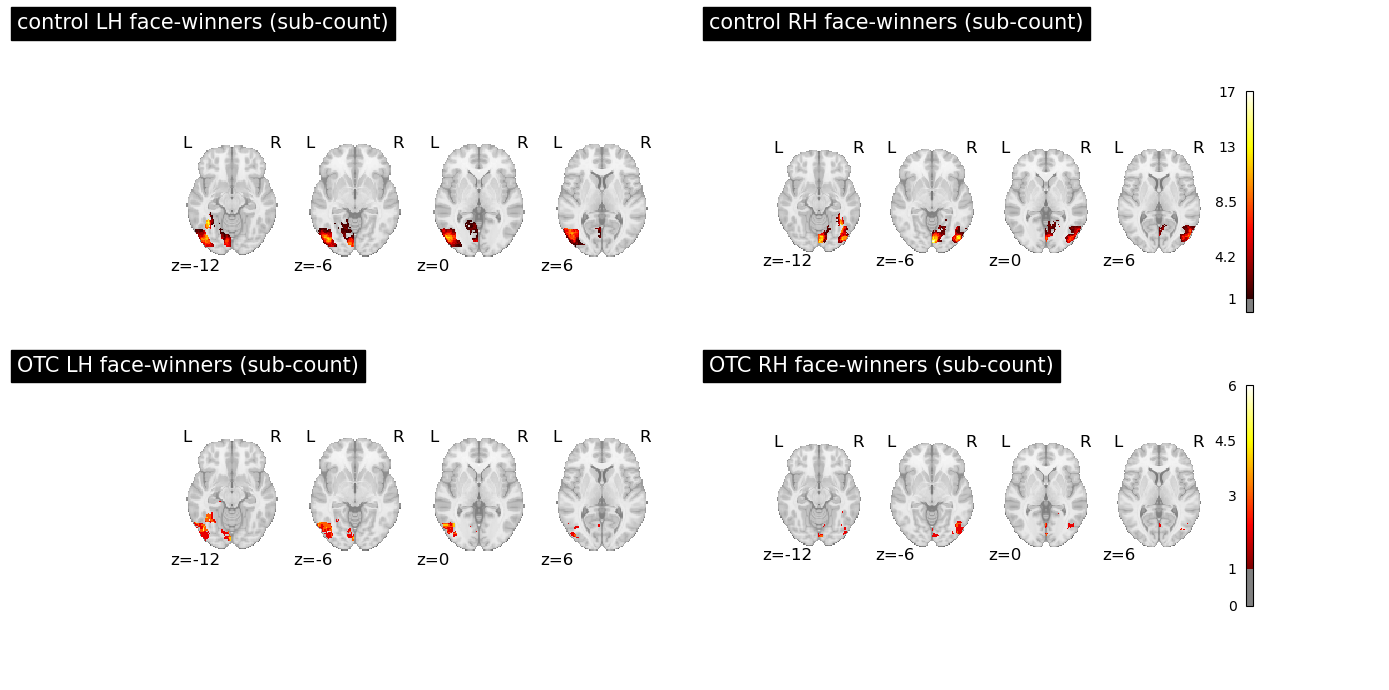

In [32]:
# ─── Where do face-winning voxels live per subject? ──────────────────────
# For each (subject, intact hemi), count face-winning voxels, find their
# centroid in MNI, compare distribution between patients and controls.
# Uses wta_data computed earlier in this notebook.

assert 'wta_data' in dir(), "Run the WTA compute cell first"

FACE_CODE = 1   # winner=1 means face won

def face_voxels_summary(d, mask_3d, affine):
    """For one subject×hemi: count of face-winners, centroid in MNI, extent."""
    winner = d['winner']
    # Reconstruct face-winner positions in 3D
    face_in_mask = (winner == FACE_CODE)
    n_face = int(face_in_mask.sum())
    if n_face == 0:
        return {'n_face': 0, 'mni_x': np.nan, 'mni_y': np.nan, 'mni_z': np.nan,
                'extent_mm': np.nan}
    # Get voxel indices of face-winners
    flat_idx_in_mask = np.where(face_in_mask)[0]
    mask_voxel_ijk = np.array(np.where(mask_3d)).T  # (n_mask_vox, 3)
    face_ijk = mask_voxel_ijk[flat_idx_in_mask]   # (n_face, 3)
    face_xyz = nib.affines.apply_affine(affine, face_ijk)
    centroid = face_xyz.mean(axis=0)
    bbox = face_xyz.max(axis=0) - face_xyz.min(axis=0)
    return {'n_face': n_face,
            'mni_x': centroid[0], 'mni_y': centroid[1], 'mni_z': centroid[2],
            'extent_mm': float(np.linalg.norm(bbox))}

rows = []
for (sid, h), d in wta_data.items():
    mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
    s = face_voxels_summary(d, mask, MNI_AFFINE)
    rows.append({'sid': sid, 'hemi': h, 'group': d['group'], **s})

df_face = pd.DataFrame(rows)

# Summary by group × hemi
print('Face-winning voxels per subject (WTA, threshold z>2.326):')
print(f"{'group':<10} {'hemi':>5} {'n':>3} {'mean_n_face':>12} {'sd_n_face':>10} "
      f"{'mean_centroid_xyz':>30}")
print('-' * 80)
for h in ['l', 'r']:
    for grp in ['control', 'OTC']:
        sub = df_face[(df_face.hemi == h) & (df_face.group == grp)]
        if len(sub) == 0: continue
        mean_n = sub['n_face'].mean()
        sd_n = sub['n_face'].std(ddof=1)
        cx, cy, cz = sub['mni_x'].mean(), sub['mni_y'].mean(), sub['mni_z'].mean()
        print(f"{grp:<10} {h.upper():>5} {len(sub):>3} {mean_n:>12.1f} {sd_n:>10.1f} "
              f"  ({cx:>5.0f}, {cy:>5.0f}, {cz:>5.0f})")

# Per-patient with face counts
print(f'\nPer-patient face-winner detail:')
print(f"{'sid':<12} {'intact':>7} {'n_face':>7} {'mni_xyz':>22} {'extent_mm':>10}")
for r in df_face[df_face.group == 'OTC'].itertuples():
    xyz = f'({r.mni_x:>4.0f},{r.mni_y:>4.0f},{r.mni_z:>4.0f})'
    print(f'{r.sid:<12} {r.hemi.upper():>7} {r.n_face:>7d} {xyz:>22} {r.extent_mm:>10.1f}')

# Plot face-winning voxels per group × hemi on brain
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for col, h in enumerate(['l', 'r']):
    mask = VOTC_MASK_LH if h == 'l' else VOTC_MASK_RH
    for row, grp in enumerate(['control', 'OTC']):
        # Stack all face-winner masks for this group × hemi
        agg = np.zeros(mask.shape, dtype=np.int32)
        for (sid, hh), d in wta_data.items():
            if hh != h or d['group'] != grp: continue
            face_mask_flat = (d['winner'] == FACE_CODE).astype(np.int32)
            face_3d = np.zeros(mask.shape, dtype=np.int32)
            face_3d[mask] = face_mask_flat
            agg += face_3d
        # Plot as ROI (count map)
        agg_img = nib.Nifti1Image(agg.astype(np.float32), MNI_AFFINE)
        plotting.plot_stat_map(
            agg_img, axes=axes[row, col], display_mode='z',
            cut_coords=[-12, -6, 0, 6], threshold=1,
            title=f'{grp} {h.upper()}H face-winners (sub-count)',
            cmap='hot', colorbar=(col == 1),
        )
plt.tight_layout()
plt.show()

# Part B — Peaks & topography
From `cross-sectional`. Fig 2C–H, 2I/J, peak-coord MNI.

In [33]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
    print(f'Merged IFG addon: +{(pd.read_csv(addon)["subject_id"]).nunique()} subj')
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls → first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients → last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

# Pairwise: filter le directly, NOT via le_summary
ctrl_pw = le[le['status'] == 'control'].merge(fs, on='subject_id')
ctrl_pw = ctrl_pw[ctrl_pw['ses_num'] == ctrl_pw['keep']].drop(columns='keep')
pt_pw = le[le['group'] == 'OTC'].merge(ls, on='subject_id')
pt_pw = pt_pw[pt_pw['ses_num'] == pt_pw['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())

print(f'Controls: {len(ctrl_subs)}')
print(f'OTC patients: {len(otc_subs)}')
print(f'  Liu overlap: {[s for s in otc_subs if s in LIU_CODES]}')
print(f'ctrl_pw rows: {len(ctrl_pw)}, pt_pw rows: {len(pt_pw)}')

Controls: 38
OTC patients: 22
  Liu overlap: ['sub-004', 'sub-021', 'sub-044', 'sub-099']
ctrl_pw rows: 5092, pt_pw rows: 1474


In [34]:
def crawford(x, c):
    """Crawford & Howell (1998) modified t, returns (t, p)."""
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def fisher_z(r):
    r = np.clip(np.asarray(r, float), -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def fdr_correct(p_values, method='bh', alpha=0.05):
    """FDR correction. 'bh' (Benjamini-Hochberg, liberal) or 'by' (Benjamini-Yekutieli).
    Returns boolean mask of significant tests."""
    p = np.asarray(p_values, float)
    valid = ~np.isnan(p)
    p_valid = p[valid]
    n = len(p_valid)
    if n == 0: return np.zeros_like(p, bool)
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    if method == 'bh':
        thresh = np.arange(1, n + 1) / n * alpha
    elif method == 'by':
        c_n = np.sum(1.0 / np.arange(1, n + 1))
        thresh = np.arange(1, n + 1) / (n * c_n) * alpha
    else:
        raise ValueError(f"method must be 'bh' or 'by', got {method!r}")
    passed = ranked <= thresh
    max_idx = np.where(passed)[0].max() if passed.any() else -1
    sig_valid = np.zeros(n, bool)
    if max_idx >= 0:
        sig_valid[order[:max_idx + 1]] = True
    sig = np.zeros_like(p, bool)
    sig[valid] = sig_valid
    return sig

def pt_intact_hemi(sub):
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

WORD_CATS = {'word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'}

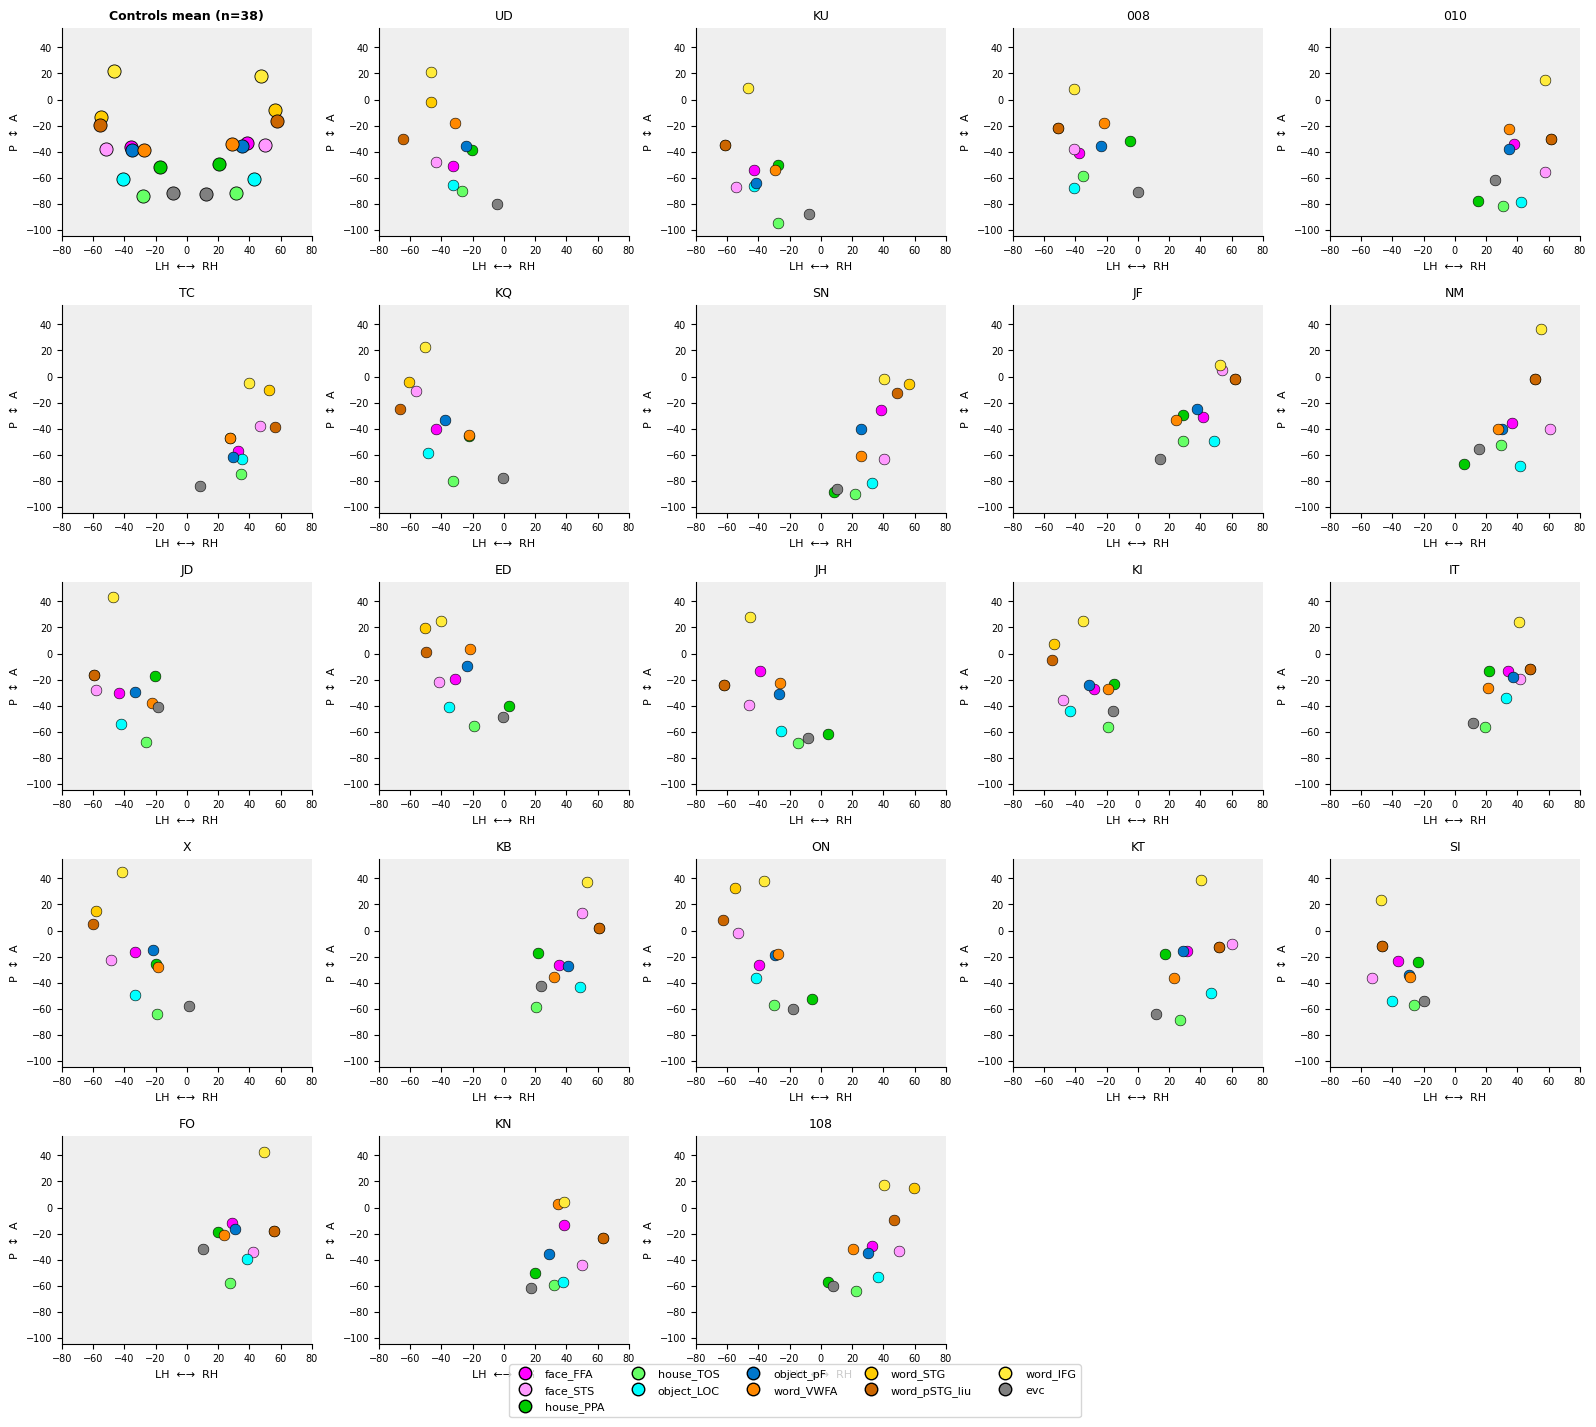

In [35]:
ROI_COLOR = {
    'face_FFA':   'magenta',  'face_STS':    '#ff99ff',
    'house_PPA':  '#00cc00',  'house_TOS':   '#66ff66',
    'object_LOC': 'cyan',     'object_pF':   '#0077cc',
    'word_VWFA':  '#ff8800',  'word_STG':    '#ffcc00',
    'word_pSTG_liu': '#cc6600',
    'word_IFG':   '#ffeb3b',
    'evc':        'gray',
}
ALL_CATS = list(ROI_COLOR.keys())
XLIM = (-80, 80); YLIM = (-105, 55)

def scatter_subject(ax, df, sub, title):
    for cat in ALL_CATS:
        for h in ('l', 'r'):
            m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
            if not len(m): continue
            ax.scatter(m['peak_x_native'].iloc[0], m['peak_y_native'].iloc[0],
                       s=60, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.4)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8)
    ax.set_ylabel('P  \u2195  A', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

n_pt  = len(otc_subs)
n_cols = 5
n_rows = int(np.ceil((n_pt + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
axes = axes.flatten()

# Controls mean (per ROI \u00d7 hemi)
ax = axes[0]
for cat in ALL_CATS:
    for h in ('l', 'r'):
        xs, ys = [], []
        for s in ctrl_subs:
            m = ctrl_le[(ctrl_le['subject_id'] == s) & (ctrl_le['category'] == cat) & (ctrl_le['hemi'] == h)]
            if len(m):
                xs.append(m['peak_x_native'].iloc[0]); ys.append(m['peak_y_native'].iloc[0])
        if xs:
            ax.scatter(np.mean(xs), np.mean(ys), s=90, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.6)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_title(f'Controls mean (n={len(ctrl_subs)})', fontsize=9, fontweight='bold')
ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8); ax.set_ylabel('P  \u2195  A', fontsize=8)
ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

for i, s in enumerate(otc_subs):
    label = SUB_CODES.get(s, s.replace('sub-', ''))
    scatter_subject(axes[i + 1], pt_le, s, label)
for j in range(n_pt + 1, len(axes)):
    axes[j].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor='k', markersize=9, label=cat)
                  for cat, c in ROI_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2CH.png', dpi=300, bbox_inches='tight')
plt.show()


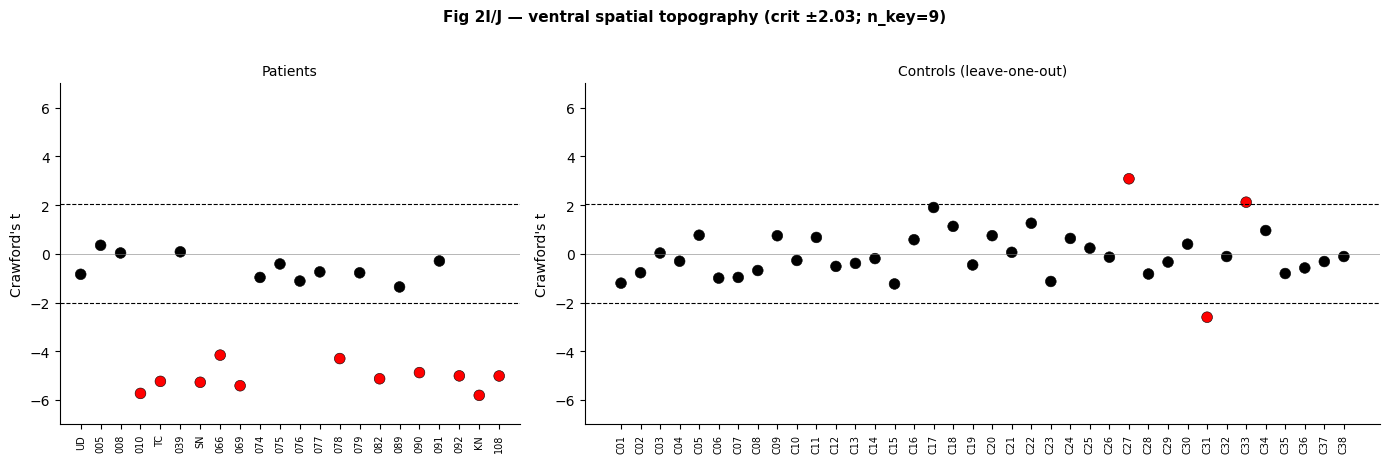

Patient t-values:    {'UD': -0.84, '005': 0.35, '008': 0.03, '010': -5.73, 'TC': -5.24, '039': 0.08, 'SN': -5.28, '066': -4.16, '069': -5.42, '074': -0.97, '075': -0.42, '076': -1.12, '077': -0.74, '078': -4.3, '079': -0.78, '082': -5.13, '089': -1.36, '090': -4.88, '091': -0.3, '092': -5.01, 'KN': -5.81, '108': -5.02}
Control t-range:     [-2.60, 3.08]


In [36]:
VENTRAL_KEY = [('evc',       'l'), ('evc',       'r'),
               ('house_PPA', 'l'), ('house_PPA', 'r'),
               ('object_pF', 'l'), ('object_pF', 'r'),
               ('face_FFA',  'l'), ('face_FFA',  'r'),
               ('word_VWFA', 'PREF')]

def resolve_hemi(hspec, is_ctrl, intact):
    if hspec in ('l', 'r'): return hspec
    if hspec == 'PREF':
        if is_ctrl: return 'l'
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

def build_xmat(df, subs, is_ctrl, intact_map):
    X = np.full((len(VENTRAL_KEY), len(subs)), np.nan)
    for i, (cat, hspec) in enumerate(VENTRAL_KEY):
        for j, s in enumerate(subs):
            h = resolve_hemi(hspec, is_ctrl, intact_map.get(s))
            if h is None: continue
            m = df[(df['subject_id'] == s) & (df['category'] == cat) & (df['hemi'] == h)]
            if len(m): X[i, j] = m['peak_x_native'].iloc[0]
    return X

intact_map = dict(zip(le_summary['subject_id'], le_summary['intact_hemi']))
X_ctrl = build_xmat(ctrl_le, ctrl_subs, True, intact_map)
X_pt   = build_xmat(pt_le,   otc_subs,  False, intact_map)
n_ctrl = len(ctrl_subs)

spcor_pt   = np.full(len(otc_subs), np.nan)
null_forpt = np.full((n_ctrl, len(otc_subs)), np.nan)
for p, s in enumerate(otc_subs):
    valid = ~np.isnan(X_pt[:, p])
    if valid.sum() < 3: continue
    pat_vec   = X_pt[valid, p]
    ctrl_sub  = X_ctrl[valid, :]
    mean_ctrl = np.nanmean(ctrl_sub, axis=1)
    ok = ~np.isnan(pat_vec) & ~np.isnan(mean_ctrl)
    if ok.sum() >= 3:
        spcor_pt[p] = np.corrcoef(pat_vec[ok], mean_ctrl[ok])[0, 1]
    for t_idx in range(n_ctrl):
        others = [c for c in range(n_ctrl) if c != t_idx]
        rest   = np.nanmean(ctrl_sub[:, others], axis=1)
        me     = ctrl_sub[:, t_idx]
        ok = ~np.isnan(me) & ~np.isnan(rest)
        if ok.sum() >= 3:
            null_forpt[t_idx, p] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_ctrl = np.full(n_ctrl, np.nan)
for c in range(n_ctrl):
    others = [j for j in range(n_ctrl) if j != c]
    rest   = np.nanmean(X_ctrl[:, others], axis=1)
    me     = X_ctrl[:, c]
    ok = ~np.isnan(me) & ~np.isnan(rest)
    if ok.sum() >= 6:
        spcor_ctrl[c] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_pt_fz   = fisher_z(spcor_pt)
null_pt_fz    = fisher_z(null_forpt)
spcor_ctrl_fz = fisher_z(spcor_ctrl)

t_pt   = np.array([crawford(spcor_pt_fz[p], null_pt_fz[:, p])[0] for p in range(len(otc_subs))])
t_ctrl = np.array([crawford(spcor_ctrl_fz[c], np.delete(spcor_ctrl_fz, c))[0] for c in range(n_ctrl)])

min_df = max(n_ctrl - 1, 3)
crit_2IJ = float(tdist.ppf(0.975, df=min_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})
pt_labels   = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(n_ctrl)]

ymax = max(7, int(np.ceil(max(np.nanmax(np.abs(t_pt)), np.nanmax(np.abs(t_ctrl))))) + 1)

for ax, xs, ts, labels, title in [
    (axes[0], np.arange(len(otc_subs)), t_pt, pt_labels, 'Patients'),
    (axes[1], np.arange(n_ctrl), t_ctrl, ctrl_labels, 'Controls (leave-one-out)'),
]:
    colors = ['red' if (not np.isnan(v) and abs(v) > crit_2IJ) else 'black' for v in ts]
    ax.scatter(xs, ts, s=60, c=colors, edgecolors='k', linewidth=0.4)
    ax.axhline( crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(-crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Crawford's t")

plt.suptitle(f'Fig 2I/J — ventral spatial topography (crit ±{crit_2IJ:.2f}; n_key={len(VENTRAL_KEY)})',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Patient t-values:    {dict(zip(pt_labels, t_pt.round(2)))}')
print(f'Control t-range:     [{np.nanmin(t_ctrl):.2f}, {np.nanmax(t_ctrl):.2f}]')

In [40]:
# ── Cell 6 setup: MNI peak-coord machinery (prereq for 6b) ────────────────────
# Reads peak_coords_mni.csv produced by calc_peak_coords_mni.py.
from matplotlib.patches import Ellipse
import matplotlib.transforms as mtransforms

MNI_CSV = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'

def confidence_ellipse(x, y, ax, n_std=1.0, **kw):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    e = Ellipse((0, 0), width=2 * rx, height=2 * ry, **kw)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (mtransforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    e.set_transform(t + ax.transData); ax.add_patch(e)

# ── Load + session filter (matches Cell 4) ────────────────────────────────────
mni = pd.read_csv(MNI_CSV)
mni = mni[~mni['subject_id'].isin(EXCLUDE)]
mni['ses_num'] = pd.to_numeric(mni['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni['subject_id'] == bad_sub) & (mni['ses_num'] == bad_ses))]

ctrl = mni[mni['status'] == 'control'].copy()
fs   = ctrl.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'k'})
ctrl = ctrl.merge(fs, on='subject_id')
ctrl = ctrl[ctrl['ses_num'] == ctrl['k']].drop(columns='k')

pt   = mni[mni['group'] == 'OTC'].copy()
ls   = pt.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'k'})
pt   = pt.merge(ls, on='subject_id')
pt   = pt[pt['ses_num'] == pt['k']].drop(columns='k')

ctrl_subs_mni = sorted(ctrl['subject_id'].unique())
pt_subs_mni   = sorted(pt['subject_id'].unique())

def coords(df, sub, roi, h):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == h)]
    if len(m) == 0: return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if (np.isnan(x) or np.isnan(y)) else (x, y)

def intact(sub):
    m = pt[pt['subject_id'] == sub]
    return None if m.empty else ('l' if m['intact_hemi'].iloc[0] == 'left' else 'r')

# Limits + midline
xlim = (-80, 80)
ylim = (-100, 0)
lx = ctrl[ctrl['hemi'] == 'l']['peak_x_mni'].mean()
rx = ctrl[ctrl['hemi'] == 'r']['peak_x_mni'].mean()
midline = (lx + rx) / 2

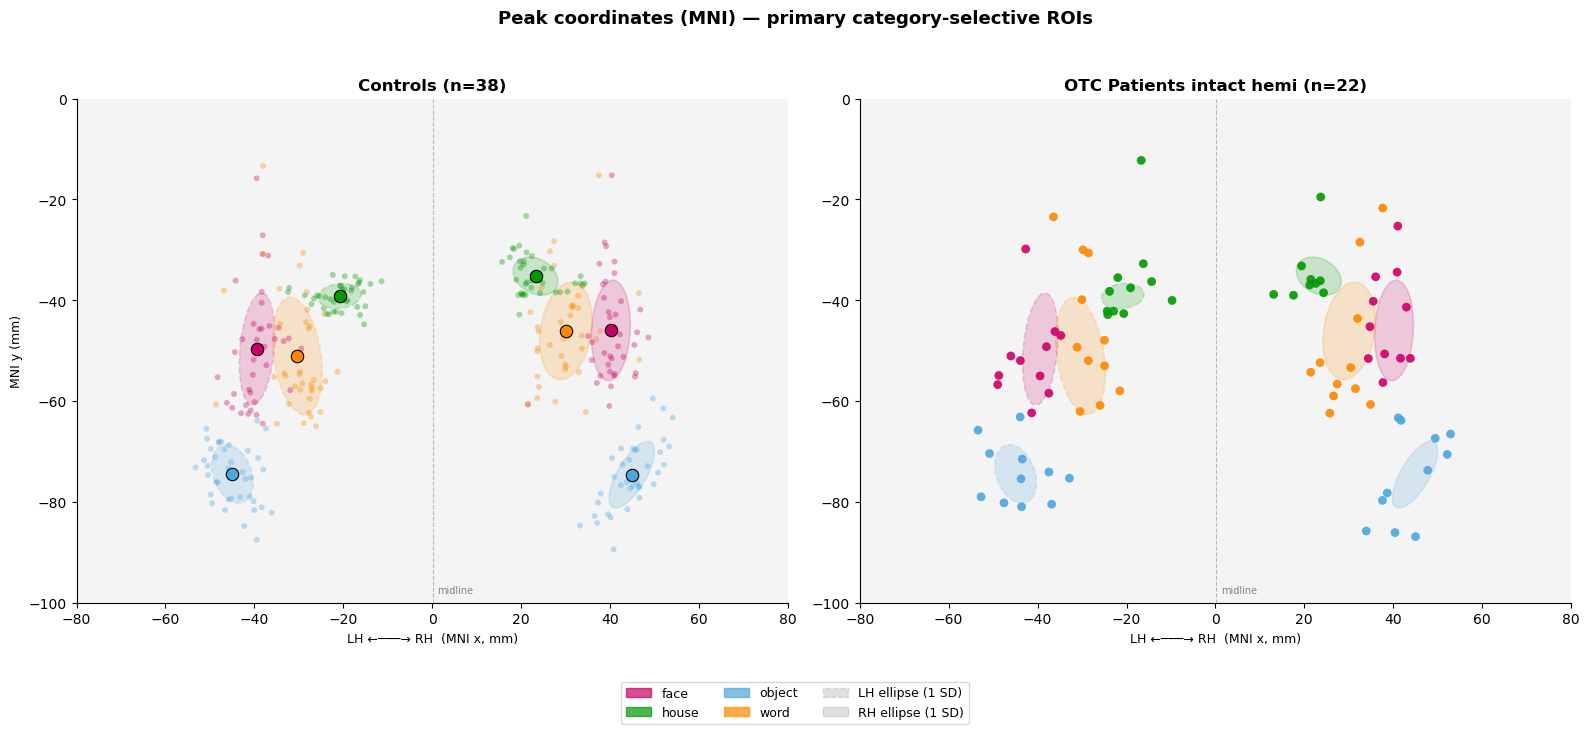

In [41]:
# ── 6b. Peak coords (MNI) — PRIMARY ROIs only (Marlene) ───────────────────────
# Run cell 6 (above) first — reuses coords/intact/confidence_ellipse, ctrl/pt,
# *_subs_mni, midline, xlim, ylim, FIG_DIR from it.
# Primary = anatomical homolog per category: face_FFA, house_PPA, object_LOC, word_VWFA.

CATS_PRIMARY = [
    ('face_FFA',   '#cc0066', 'face'),
    ('house_PPA_strict',  '#009900', 'house'),
    ('object_LOC', '#4da6e0', 'object'),
    ('word_VWFA',  '#ff8800', 'word'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color, _ in CATS_PRIMARY:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [coords(ctrl, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3: continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0,
                               facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2, linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=18, edgecolors='none', zorder=3)
                ax.scatter(x.mean(), y.mean(), color=color, s=80,
                           edgecolors='black', linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact(sub)
                if pt_h is None: continue
                p = coords(pt, sub, roi, pt_h)
                if p is None: continue
                ax.scatter(p[0], p[1], color=color, s=40,
                           edgecolors='none', alpha=0.9, zorder=6)

    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=7, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←───→ RH  (MNI x, mm)', fontsize=9)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=12, fontweight='bold')
    else:
        ax.set_title(f'OTC Patients intact hemi (n={len(pt_subs_mni)})',
                     fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=lab) for _, c, lab in CATS_PRIMARY]
leg += [
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--', label='LH ellipse (1 SD)'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',  label='RH ellipse (1 SD)'),
]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — primary category-selective ROIs',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni_primary.png', dpi=300, bbox_inches='tight')
plt.show()

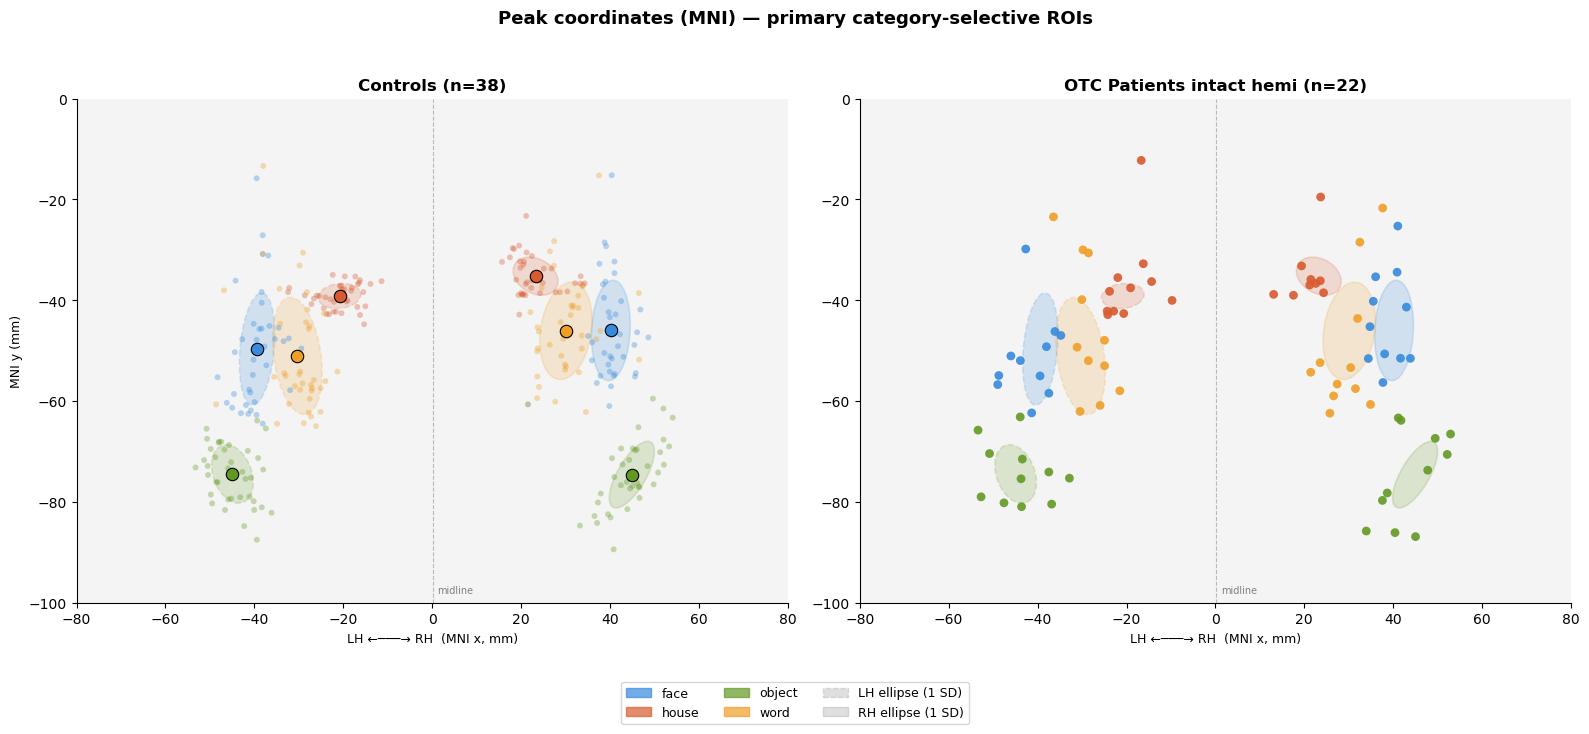

In [42]:
# ── 6b. Peak coords (MNI) — PRIMARY ROIs only (Marlene) ───────────────────────
# Run cell 6 (above) first — reuses coords/intact/confidence_ellipse, ctrl/pt,
# *_subs_mni, midline, xlim, ylim, FIG_DIR from it.
# Primary = anatomical homolog per category: face_FFA, house_PPA, object_LOC, word_VWFA.
CATS_PRIMARY = [
    ('face_FFA',          '#378ADD', 'face'),
    ('house_PPA_strict',  '#D85A30', 'house'),
    ('object_LOC',        '#639922', 'object'),
    ('word_VWFA',         '#EF9F27', 'word'),
]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color, _ in CATS_PRIMARY:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [coords(ctrl, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3: continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0,
                               facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2, linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=18, edgecolors='none', zorder=3)
                ax.scatter(x.mean(), y.mean(), color=color, s=80,
                           edgecolors='black', linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact(sub)
                if pt_h is None: continue
                p = coords(pt, sub, roi, pt_h)
                if p is None: continue
                ax.scatter(p[0], p[1], color=color, s=40,
                           edgecolors='none', alpha=0.9, zorder=6)
    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=7, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←───→ RH  (MNI x, mm)', fontsize=9)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=12, fontweight='bold')
    else:
        ax.set_title(f'OTC Patients intact hemi (n={len(pt_subs_mni)})',
                     fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=lab) for _, c, lab in CATS_PRIMARY]
leg += [
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--', label='LH ellipse (1 SD)'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',  label='RH ellipse (1 SD)'),
]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — primary category-selective ROIs',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni_primary.png', dpi=300, bbox_inches='tight')
plt.show()

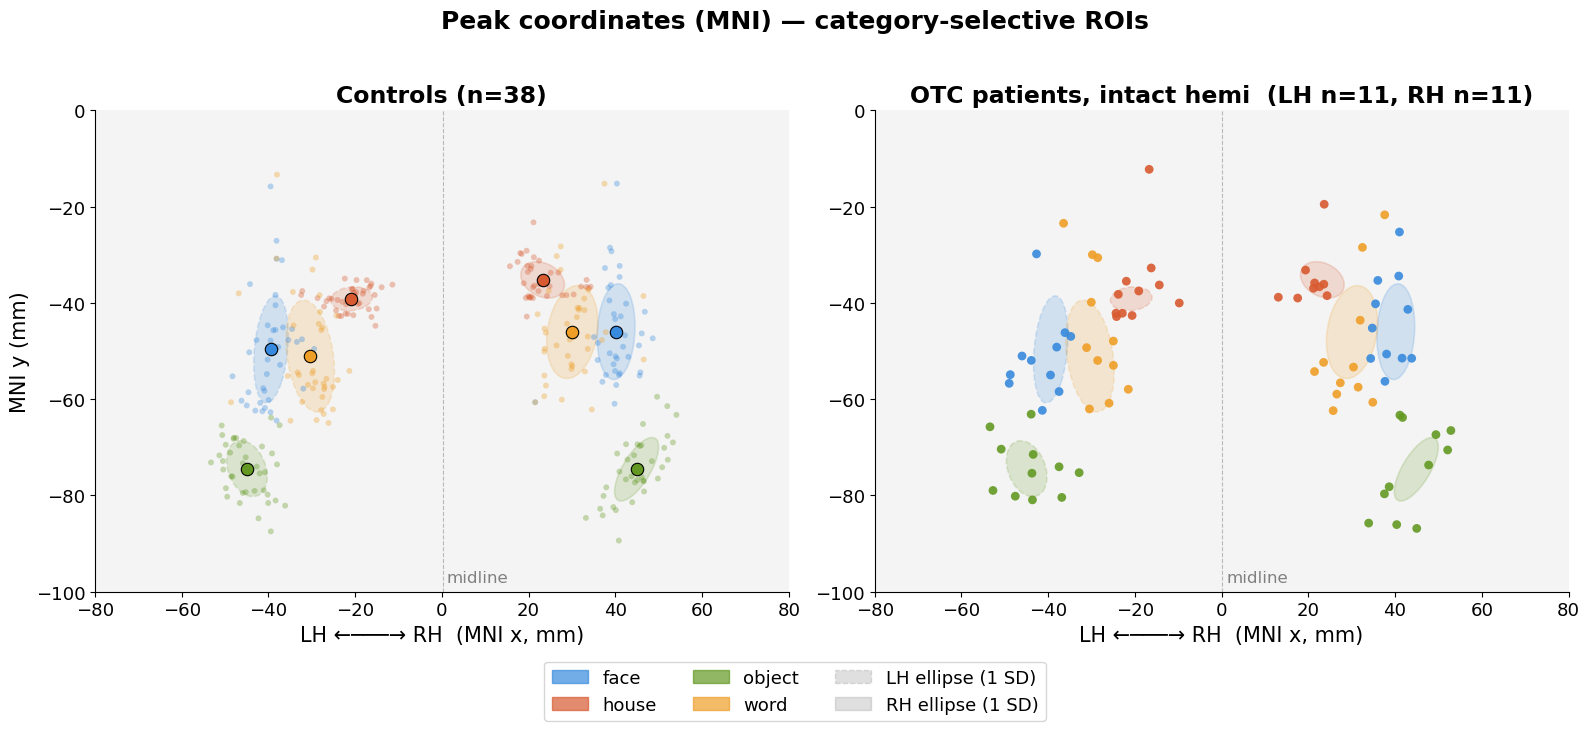

In [44]:
# ── 6b. Peak coords (MNI) — PRIMARY ROIs only (Marlene) ───────────────────────
# Run cell 6 setup (above) first — reuses coords/intact/confidence_ellipse, ctrl/pt,
# *_subs_mni, midline, xlim, ylim, FIG_DIR from it.
# Primary = anatomical homolog per category: face_FFA, house_PPA, object_LOC, word_VWFA.
CATS_PRIMARY = [
    ('face_FFA',          '#378ADD', 'face'),
    ('house_PPA_strict',  '#D85A30', 'house'),
    ('object_LOC',        '#639922', 'object'),
    ('word_VWFA',         '#EF9F27', 'word'),
]

# Per-hemisphere patient counts (total n is split across intact hemispheres)
n_lh = sum(1 for s in pt_subs_mni if intact(s) == 'l')
n_rh = sum(1 for s in pt_subs_mni if intact(s) == 'r')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color, _ in CATS_PRIMARY:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [coords(ctrl, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3: continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0,
                               facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2, linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=18, edgecolors='none', zorder=3)
                ax.scatter(x.mean(), y.mean(), color=color, s=80,
                           edgecolors='black', linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact(sub)
                if pt_h is None: continue
                p = coords(pt, sub, roi, pt_h)
                if p is None: continue
                ax.scatter(p[0], p[1], color=color, s=40,
                           edgecolors='none', alpha=0.9, zorder=6)
    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=12, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←───→ RH  (MNI x, mm)', fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=15)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=17, fontweight='bold')
    else:
        ax.set_title(f'OTC patients, intact hemi  (LH n={n_lh}, RH n={n_rh})',
                     fontsize=17, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=lab) for _, c, lab in CATS_PRIMARY]
leg += [
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--', label='LH ellipse (1 SD)'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',  label='RH ellipse (1 SD)'),
]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=13, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — category-selective ROIs',
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni_primary.png', dpi=300, bbox_inches='tight')
plt.show()

# Part C — RSA geometry
From `category_rsa_geometry`. Distinctiveness, RDM triptychs, Procrustes (viz only).

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.spatial import procrustes
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

sys.path.insert(0, "/user_data/csimmon2/git_repos/sym_pt")
from sym_pt_params import processed_dir

np.random.seed(0)
MNI_CSV     = Path(processed_dir) / "group_results" / "peak_coords" / "peak_coords_mni.csv"
ROIS        = ["face_FFA", "house_PPA", "object_LOC", "word_VWFA"]
CATS4       = ["face", "object", "house", "word"]
N_PERM      = 10_000
HEMIS       = {"l": "left", "r": "right"}
EXCLUDE     = ["sub-017"]
EXCLUDE_SES = [("sub-108", 2)]

In [ ]:
mni = pd.read_csv(MNI_CSV)
mni = mni[~mni["subject_id"].isin(EXCLUDE)].copy()
mni["ses_num"] = pd.to_numeric(mni["session"], errors="coerce").astype("Int64")
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni["subject_id"] == bad_sub) & (mni["ses_num"] == bad_ses))]
mni = mni[mni["category"].isin(ROIS) & mni["pair"].notna()].copy()

ls = (mni[mni["group"]=="OTC"].groupby("subject_id")["ses_num"].max()
        .reset_index().rename(columns={"ses_num":"keep"}))
pt = mni[mni["group"]=="OTC"].merge(ls, on="subject_id"); pt = pt[pt["ses_num"]==pt["keep"]].drop(columns="keep")
fs = (mni[mni["status"]=="control"].groupby("subject_id")["ses_num"].min()
        .reset_index().rename(columns={"ses_num":"keep"}))
ct = mni[mni["status"]=="control"].merge(fs, on="subject_id"); ct = ct[ct["ses_num"]==ct["keep"]].drop(columns="keep")
df = pd.concat([pt, ct], ignore_index=True)

df["pair_sorted"] = df["pair"].apply(lambda p: "-".join(sorted(p.split("-"))))
PAIRS_SORTED = sorted(df["pair_sorted"].unique())
assert len(PAIRS_SORTED) == 6, f"expected 6 pairs, got {PAIRS_SORTED}"
df = df.drop(columns=["pair"])
df["is_pt"] = (df["status"] == "patient").astype(int)

print("patients:", df[df.is_pt==1]["subject_id"].nunique(), "| controls:", df[df.is_pt==0]["subject_id"].nunique())
print(df.groupby(["category","hemi","status"])["subject_id"].nunique().unstack(fill_value=0))

patients: 22 | controls: 38
status           control  patient
category   hemi                  
face_FFA   l          38       11
           r          38       11
house_PPA  l          38       11
           r          38       11
object_LOC l          38       11
           r          38       11
word_VWFA  l          38       11
           r          38       11


In [ ]:
def stratum(df, roi, hemi):
    s = df[(df["category"] == roi) & (df["hemi"] == hemi)].copy()
    s["group"] = np.where(s["is_pt"] == 1, "patient", "control")
    return s

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return np.nan if sp == 0 else (np.mean(x) - np.mean(y)) / sp

def perm_test(x, y, n=N_PERM, rng=None):
    rng = rng or np.random.default_rng(0)
    obs = np.mean(x) - np.mean(y)
    pool = np.concatenate([x, y]); nx = len(x)
    null = np.empty(n)
    for i in range(n):
        rng.shuffle(pool); null[i] = np.mean(pool[:nx]) - np.mean(pool[nx:])
    return obs, (np.sum(np.abs(null) >= abs(obs)) + 1) / (n + 1)

def bh_fdr(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 1.0
    for k in range(m-1, -1, -1):
        i = order[k]; run = min(run, p[i] * m / (k+1)); adj[i] = run
    return adj

def subj_rdm(sub_rows):
    M = np.eye(4)
    for _, row in sub_rows.iterrows():
        a, b = row["pair_sorted"].split("-"); i, j = CATS4.index(a), CATS4.index(b)
        M[i, j] = M[j, i] = np.tanh(row["fisher_r"])
    return M

def coords(sim_mat):
    M = np.where(np.isnan(sim_mat), 0.0, sim_mat)
    np.fill_diagonal(M, 1.0)
    return MDS(n_components=2, dissimilarity="precomputed", random_state=0,
               normalized_stress="auto").fit_transform(1.0 - M)

def subj_mats(s, grp):
    return {sid: subj_rdm(g) for sid, g in s[s.group == grp].groupby("subject_id")
            if g["pair_sorted"].nunique() == 6}

In [ ]:
dist = (df.drop_duplicates(["subject_id","category","hemi"])
          [["subject_id","category","hemi","is_pt","liu_distinctiveness"]].copy())
dist["group"] = np.where(dist["is_pt"] == 1, "patient", "control")

rng = np.random.default_rng(0)
rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = dist[(dist.category == roi) & (dist.hemi == hemi)]
        x = s.loc[s.group=="patient","liu_distinctiveness"].dropna().values
        y = s.loc[s.group=="control","liu_distinctiveness"].dropna().values
        if len(x) < 2 or len(y) < 2:
            rows.append(dict(roi=roi, hemi=hemi, n_pt=len(x), n_ct=len(y), diff=np.nan, d=np.nan, p=np.nan)); continue
        diff, p = perm_test(x, y, rng=rng)
        rows.append(dict(roi=roi, hemi=hemi, n_pt=len(x), n_ct=len(y),
                         ctrl=y.mean(), pt=x.mean(), diff=diff, d=cohen_d(x, y), p=p))
distinct = pd.DataFrame(rows)
distinct.round(4)

,roi,hemi,n_pt,n_ct,ctrl,pt,diff,d,p
0,face_FFA,l,11,38,0.6711,0.5694,-0.1016,-0.3028,0.3770
1,face_FFA,r,11,37,0.5476,0.7184,0.1708,0.4610,0.1792
2,house_PPA,l,11,38,0.4359,0.1159,-0.3200,-0.4374,0.2128
3,house_PPA,r,11,38,0.4951,0.8260,0.3308,0.4141,0.2360
4,object_LOC,l,11,38,1.0507,1.0350,-0.0158,-0.0365,0.9128
5,object_LOC,r,11,38,1.2320,1.2795,0.0475,0.0956,0.7815
6,word_VWFA,l,11,37,0.6374,0.5749,-0.0624,-0.1454,0.6724
7,word_VWFA,r,11,37,0.3648,0.7250,0.3601,0.7369,0.0406


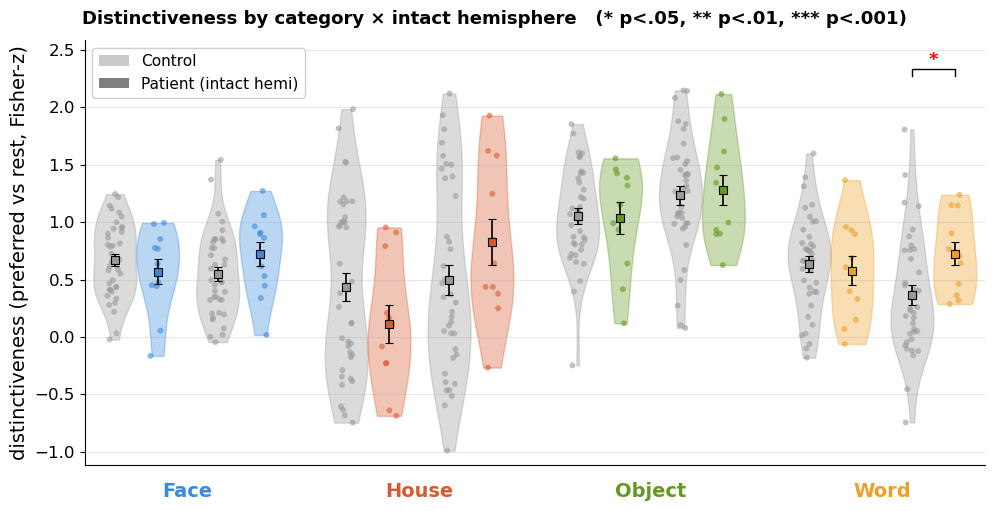

In [ ]:
# ─── Distinctiveness (measure 1): violins matching sum-sel layout ────────
from matplotlib.patches import Patch

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30', 'object': '#639922', 'word': '#EF9F27'}
ROI_FOR = {'face': 'face_FFA', 'house': 'house_PPA', 'object': 'object_LOC', 'word': 'word_VWFA'}
CATS_PANEL = ['face', 'house', 'object', 'word']
CTRL_COLOR = '#999999'

def _stars(p):
    if np.isnan(p): return ''
    return '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''

dd = (df.drop_duplicates(["subject_id","category","hemi"])
        [["subject_id","category","hemi","is_pt","liu_distinctiveness"]].copy())
dd["group"] = np.where(dd["is_pt"]==1, "patient", "control")

INTRA, INTER, CAT_GAP = 0.5, 0.7, 1.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(10, 5))
RNG = np.random.RandomState(42)
cat_centers = []

allv = dd['liu_distinctiveness'].dropna().values
gmin, gmax = allv.min(), allv.max()
brack_h = (gmax - gmin) * 0.02

def _get(cat, h, grp):
    return dd[(dd.category==ROI_FOR[cat]) & (dd.hemi==h) & (dd.group==grp)]['liu_distinctiveness'].dropna().values

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    groups = [
        (_get(cat,'l','control'), positions[0], CTRL_COLOR),
        (_get(cat,'l','patient'), positions[1], cat_color),
        (_get(cat,'r','control'), positions[2], CTRL_COLOR),
        (_get(cat,'r','patient'), positions[3], cat_color),
    ]
    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        jit = RNG.uniform(-0.09, 0.09, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals, color=col, alpha=0.6, s=18, edgecolors='none', zorder=3)
        ax.errorbar(pos, vals.mean(), yerr=vals.std()/np.sqrt(max(len(vals),1)),
                    color='black', marker='s', markersize=6, markerfacecolor=col,
                    markeredgecolor='black', markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    for (h, x_l, x_r) in [('l', positions[0], positions[1]), ('r', positions[2], positions[3])]:
        row = distinct[(distinct.roi==ROI_FOR[cat]) & (distinct.hemi==h)]
        stars = _stars(float(row['p'].iloc[0])) if len(row) else ''
        if not stars: continue
        by = gmax + brack_h * 2
        ax.plot([x_l, x_l, x_r, x_r], [by, by+brack_h, by+brack_h, by], color='black', lw=1, zorder=6)
        ax.text((x_l+x_r)/2, by+brack_h, stars, ha='center', va='bottom', color='red', fontsize=13, fontweight='bold', zorder=6)

ax.set_xticks([])
ax.set_ylabel('distinctiveness (preferred vs rest, Fisher-z)', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
            color=CAT_COLORS[cat], ha='center', va='top', transform=ax.get_xaxis_transform())

total_width = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
ax.set_xlim(-0.35, total_width + 0.35)
yrange = gmax - gmin
ax.set_ylim(gmin - 0.04*yrange, gmax + 0.14*yrange)

legend_elements = [Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control'),
                   Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi)')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, framealpha=0.9)

plt.suptitle('Distinctiveness by category × intact hemisphere   (* p<.05, ** p<.01, *** p<.001)',
             fontsize=13, fontweight='bold', y=0.99)
plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
plt.savefig(FIG_DIR / 'distinctiveness_violin.png', dpi=300, bbox_inches='tight')
plt.show()

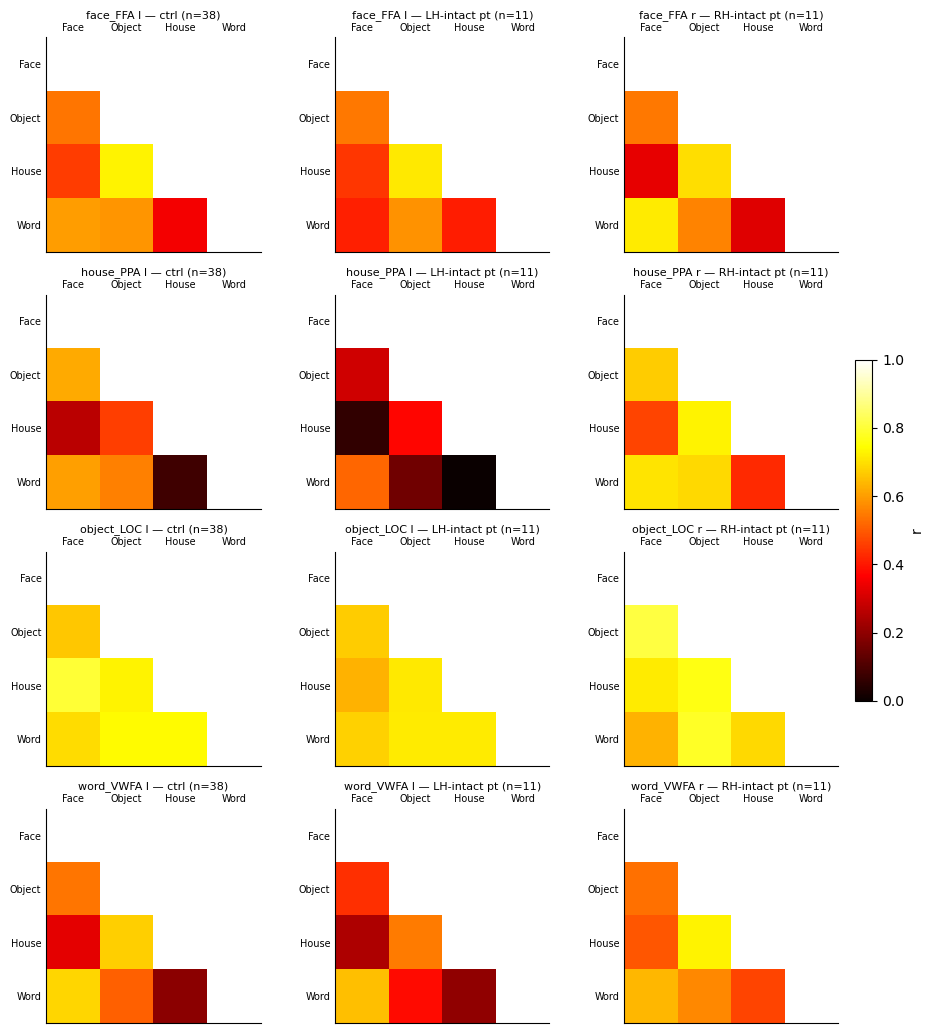

Procrustes disparity, patient vs control (higher = worse fit to control geometry):
       roi hemi  mean_pt  mean_ct    diff      p
  face_FFA    l   0.2610   0.2750 -0.0140 0.8093
  face_FFA    r   0.3233   0.2503  0.0729 0.1737
 house_PPA    l   0.3970   0.4271 -0.0301 0.7761
 house_PPA    r   0.3756   0.3463  0.0293 0.7377
object_LOC    l   0.4798   0.4358  0.0440 0.5726
object_LOC    r   0.4497   0.4724 -0.0226 0.7563
 word_VWFA    l   0.3053   0.2528  0.0525 0.4595
 word_VWFA    r   0.3484   0.1780  0.1704 0.0039


In [ ]:
def mean_rdm(s, grp):
    mats = list(subj_mats(s, grp).values())
    return (np.nanmean(np.stack(mats), axis=0), len(mats)) if mats else (np.full((4,4), np.nan), 0)

LAB = ["Face","Object","House","Word"]
fig, axes = plt.subplots(len(ROIS), 3, figsize=(11, 3.2*len(ROIS)))
for ri, roi in enumerate(ROIS):
    sl = stratum(df, roi, "l"); sr = stratum(df, roi, "r")
    panels = [(mean_rdm(sl, "control"), f"{roi} l — ctrl"),
              (mean_rdm(sl, "patient"), f"{roi} l — LH-intact pt"),
              (mean_rdm(sr, "patient"), f"{roi} r — RH-intact pt")]
    for ci, ((M, nrdm), ttl) in enumerate(panels):
        ax = axes[ri, ci]
        M = np.where(np.triu(np.ones_like(M, bool), k=1), np.nan, M)  # hide upper triangle (# if want full matrix))
        im = ax.imshow(M, cmap="hot", vmin=0, vmax=1)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(LAB, fontsize=7); ax.set_yticklabels(LAB, fontsize=7)
        ax.xaxis.tick_top(); ax.set_title(f"{ttl} (n={nrdm})", fontsize=8, pad=14)
        ax.tick_params(length=0)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="r")
plt.show()

disp_rows = []
for roi in ROIS:
    for hemi in HEMIS:
        s = stratum(df, roi, hemi)
        ctrl = subj_mats(s, "control"); pat = subj_mats(s, "patient")
        if len(ctrl) < 2: continue
        cmats = np.stack(list(ctrl.values())); cm = coords(np.nanmean(cmats, axis=0))
        for k, sid in enumerate(ctrl):
            loo = np.nanmean(np.delete(cmats, k, axis=0), axis=0)
            _, _, d = procrustes(coords(loo), coords(ctrl[sid]))
            disp_rows.append(dict(roi=roi, hemi=hemi, group="control", disparity=d))
        for sid, M in pat.items():
            _, _, d = procrustes(cm, coords(M))
            disp_rows.append(dict(roi=roi, hemi=hemi, group="patient", disparity=d))
disp = pd.DataFrame(disp_rows)
rng = np.random.default_rng(0)
dt = []
for (roi, hemi), g in disp.groupby(["roi","hemi"]):
    x = g.loc[g.group=="patient","disparity"].values; y = g.loc[g.group=="control","disparity"].values
    if len(x) < 2 or len(y) < 2: continue
    diff, p = perm_test(x, y, rng=rng)
    dt.append(dict(roi=roi, hemi=hemi, mean_pt=x.mean(), mean_ct=y.mean(), diff=diff, p=p))
print("Procrustes disparity, patient vs control (higher = worse fit to control geometry):")
print(pd.DataFrame(dt).round(4).to_string(index=False))

In [ ]:
# ─── Measures 2+3: RDM triptych (ctrl | patient | difference) per ROI ────
def mean_rdm(s, grp):
    mats = list(subj_mats(s, grp).values())
    return (np.nanmean(np.stack(mats), axis=0), len(mats)) if mats else (np.full((4,4), np.nan), 0)

LAB = ['Face','Object','House','Word']

def _mask_upper(M):
    return np.where(np.triu(np.ones_like(M, bool), k=1), np.nan, M)

PLOT = [('face_FFA','r'), ('word_VWFA','r'), ('face_FFA','l')]

# global symmetric scale across all difference panels
dmax = 0.0
for roi, hemi in PLOT:
    s = stratum(df, roi, hemi)
    C, _ = mean_rdm(s, 'control'); P, _ = mean_rdm(s, 'patient')
    D = P - C; np.fill_diagonal(D, np.nan)
    if np.isfinite(D).any():
        dmax = max(dmax, np.nanmax(np.abs(D)))

def plot_rdm_diff(roi, hemi, gdmax):
    s = stratum(df, roi, hemi)
    C, nc = mean_rdm(s, 'control')
    P, npt = mean_rdm(s, 'patient')
    D = P - C
    np.fill_diagonal(D, np.nan)

    o = omni[(omni.roi==roi) & (omni.hemi==hemi)].iloc[0]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))

    specs = [(_mask_upper(C), f'control (n={nc})', 'hot', 0, 1, 'r'),
             (_mask_upper(P), f'patient (n={npt})', 'hot', 0, 1, 'r'),
             (_mask_upper(D), 'patient − control', 'RdBu_r', -gdmax, gdmax, 'Δr')]
    for ax, (M, ttl, cmap, vmin, vmax, cbar_lab) in zip(axes, specs):
        im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(LAB, fontsize=9); ax.set_yticklabels(LAB, fontsize=9)
        ax.xaxis.tick_top(); ax.tick_params(length=0)
        ax.set_title(ttl, fontsize=10, pad=14)
        if cbar_lab == 'Δr':
            for pr in PAIRS_SORTED:
                row = posthoc[(posthoc.roi==roi)&(posthoc.hemi==hemi)&(posthoc.pair==pr)]
                if len(row) and bool(row['survives'].iloc[0]):
                    a, b = pr.split('-'); i, j = LAB.index(a.title()), LAB.index(b.title())
                    lo, hi = max(i,j), min(i,j)
                    ax.text(hi, lo, '*', ha='center', va='center', color='black',
                            fontsize=20, fontweight='bold')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_lab)

    p_str = "p < .001" if o["p"] < .001 else f"p = {o['p']:.3f}"
    fig.suptitle(f'{roi}  |  {HEMIS[hemi]} hemisphere   ·   '
                 f'interaction χ²(5)={o["chi2"]:.1f}, {p_str}',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'rdm_diff_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()

for roi, hemi in PLOT:
    plot_rdm_diff(roi, hemi, dmax)
    
    

NameError: name 'omni' is not defined

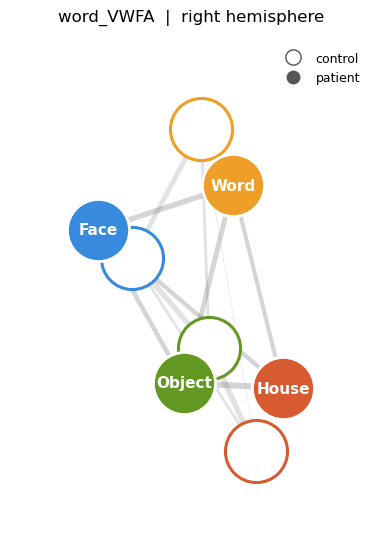

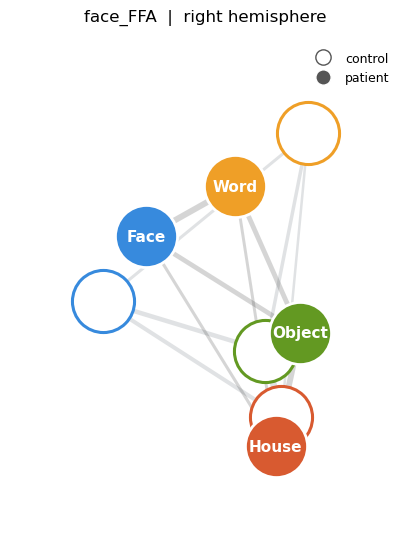

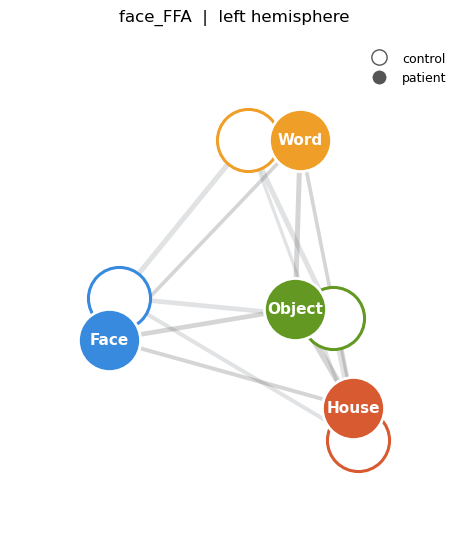

In [ ]:
# ─── Procrustes/MDS configuration plots — selected ROI × hemi ────────────
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30', 'object': '#639922', 'word': '#EF9F27'}
PAIRS6 = [('face','object'),('face','house'),('face','word'),
          ('house','object'),('object','word'),('house','word')]

def aligned_configs(s):
    cmats = list(subj_mats(s, 'control').values())
    pmats = list(subj_mats(s, 'patient').values())
    if len(cmats) < 2 or len(pmats) < 1:
        return None
    csim = np.nanmean(np.stack(cmats), axis=0)
    psim = np.nanmean(np.stack(pmats), axis=0)
    mtx1, mtx2, _ = procrustes(coords(csim), coords(psim))
    return csim, psim, mtx1, mtx2

def plot_procrustes(roi, hemi):
    s = stratum(df, roi, hemi)
    out = aligned_configs(s)
    if out is None:
        return
    csim, psim, c_xy, p_xy = out

    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.set_facecolor('white')

    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(csim[i, j]), 0, 1)
        ax.plot([c_xy[i,0], c_xy[j,0]], [c_xy[i,1], c_xy[j,1]], color='#9aa0a6',
                lw=0.4 + r*5.5, alpha=0.30, solid_capstyle='round', zorder=1)
    for a, b in PAIRS6:
        i, j = CATS4.index(a), CATS4.index(b)
        r = np.clip(np.nan_to_num(psim[i, j]), 0, 1)
        ax.plot([p_xy[i,0], p_xy[j,0]], [p_xy[i,1], p_xy[j,1]], color='#444',
                lw=0.4 + r*5.5, alpha=0.22, solid_capstyle='round', zorder=2)

    for k, cat in enumerate(CATS4):
        ax.scatter(*c_xy[k], s=2000, facecolor='white', edgecolor=CAT_COLORS[cat],
                   linewidth=2.2, zorder=4)
        ax.scatter(*p_xy[k], s=2000, facecolor=CAT_COLORS[cat], edgecolor='white',
                   linewidth=2.0, zorder=5)
        ax.annotate(cat.capitalize(), p_xy[k], fontsize=11, fontweight='bold',
                    color='white', ha='center', va='center', zorder=6)

    ax.set_title(f'{roi}  |  {HEMIS[hemi]} hemisphere', fontsize=12, pad=14)
    ax.set_aspect('equal'); ax.axis('off')
    pad = 0.35
    allxy = np.vstack([c_xy, p_xy])
    ax.set_xlim(allxy[:,0].min()-pad, allxy[:,0].max()+pad)
    ax.set_ylim(allxy[:,1].min()-pad, allxy[:,1].max()+pad)

    legend = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
                         markeredgecolor='#555', markersize=11, label='control'),
              plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#555',
                         markersize=11, label='patient')]
    ax.legend(handles=legend, loc='upper right', frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f'procrustes_{roi}_{hemi}.png', dpi=300, bbox_inches='tight')
    plt.show()

SELECTED = [("word_VWFA", "r"), ("face_FFA", "r"), ("face_FFA", "l")]
for roi, hemi in SELECTED:
    plot_procrustes(roi, hemi)

# Part D — Sum-selectivity
From `cross-sectional` (cell 25 base): ctrl-vs-patient violins, BH-FDR; LH-vs-RH brackets disabled.

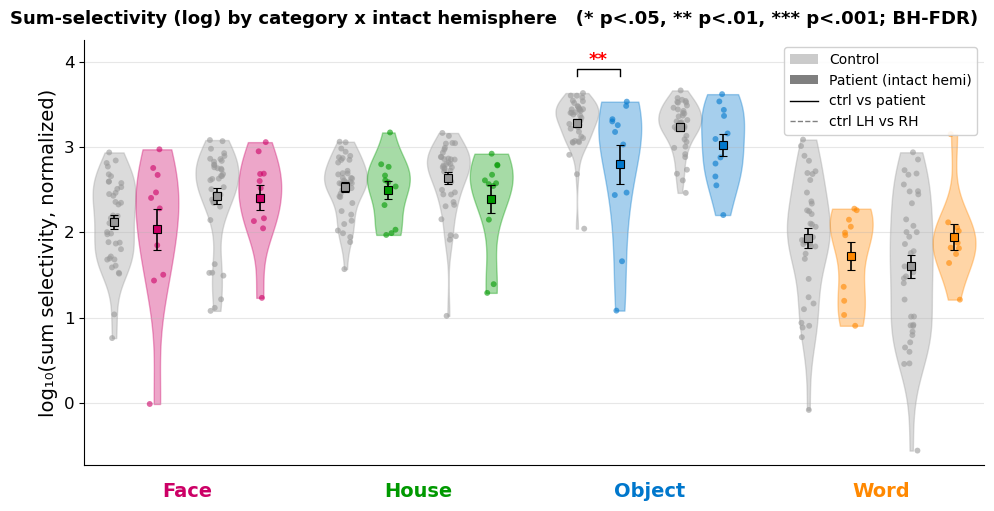

In [48]:
# Sum-selectivity violin: per category x intact hemi + significance markers
CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}
CTRL_COLOR = '#999999'

SHOW_CTRL_PT_SIG = True    # brackets: ctrl vs pt, within each hemisphere
SHOW_CTRL_LR_SIG = False    # brackets: control LH vs RH asymmetry (paired)
USE_FDR          = True    # BH-FDR within each comparison family

def collapse_log_sumsel(df, subject, category, hemi):
    sub = df[(df['subject_id'] == subject) &
             (df['category'].isin(CAT_SUBROIS[category])) &
             (df['hemi'] == hemi)].drop_duplicates(subset=['subject_id','category','hemi'])
    vals = sub['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_SUBROIS:
            for h in ('l', 'r'):
                v = collapse_log_sumsel(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_ss = build_table(ctrl_le, ctrl_subs)
pt_ss   = build_table(pt_le,   otc_subs)

intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_ss['intact_hemi'] = pt_ss['subject_id'].map(intact_lookup)
pt_ss = pt_ss[
    ((pt_ss['intact_hemi'] == 'left')  & (pt_ss['hemi'] == 'l')) |
    ((pt_ss['intact_hemi'] == 'right') & (pt_ss['hemi'] == 'r'))
]

# ── Significance tests ───────────────────────────────────────────────────────
from statsmodels.stats.multitest import multipletests
N_PERM = 10000
_rng = np.random.default_rng(42)

def _perm_indep(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 3 or len(b) < 2: return np.nan
    obs = a.mean() - b.mean()
    pool = np.concatenate([a, b]); n_a = len(a)
    null = np.array([(_rng.permutation(pool)[:n_a].mean() -
                      _rng.permutation(pool)[n_a:].mean()) for _ in range(N_PERM)])
    return ((np.abs(null) >= abs(obs)).sum() + 1) / (N_PERM + 1)

def _perm_paired(a, b):
    diff = np.asarray(a) - np.asarray(b)
    if len(diff) < 2: return np.nan
    obs = diff.mean()
    null = np.array([(_rng.choice([-1, 1], size=len(diff)) * diff).mean()
                     for _ in range(N_PERM)])
    return ((np.abs(null) >= abs(obs)).sum() + 1) / (N_PERM + 1)

def _stars(p):
    if np.isnan(p): return ''
    if p < .001: return '***'
    if p < .01:  return '**'
    if p < .05:  return '*'
    return ''

def _fdr(pdict):
    cats = [c for c in pdict if not np.isnan(pdict[c])]
    if not cats: return pdict
    _, adj, _, _ = multipletests([pdict[c] for c in cats], method='fdr_bh')
    out = dict(pdict)
    for c, q in zip(cats, adj):
        out[c] = q
    return out

# ctrl vs pt, per hemisphere (independent)
p_ctrlpt = {}
for h in ('l', 'r'):
    pd_h = {}
    for cat in CAT_SUBROIS:
        c = ctrl_ss[(ctrl_ss['category']==cat) & (ctrl_ss['hemi']==h)]['val'].values
        p = pt_ss[(pt_ss['category']==cat) & (pt_ss['hemi']==h)]['val'].values
        pd_h[cat] = _perm_indep(c, p)
    p_ctrlpt[h] = _fdr(pd_h) if USE_FDR else pd_h

# control LH vs RH (paired, same subjects both hemis)
p_ctrlLR = {}
for cat in CAT_SUBROIS:
    l = ctrl_ss[(ctrl_ss['category']==cat) & (ctrl_ss['hemi']=='l')].set_index('subject_id')['val']
    r = ctrl_ss[(ctrl_ss['category']==cat) & (ctrl_ss['hemi']=='r')].set_index('subject_id')['val']
    common = l.index.intersection(r.index)
    p_ctrlLR[cat] = _perm_paired(l.loc[common].values, r.loc[common].values)
p_ctrlLR = _fdr(p_ctrlLR) if USE_FDR else p_ctrlLR

CATS_PANEL = ['face', 'house', 'object', 'word']
INTRA, INTER, CAT_GAP = 0.5, 0.7, 1.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(10, 5))
RNG = np.random.RandomState(42)
cat_centers = []

all_vals_global = np.concatenate([ctrl_ss['val'].dropna().values, pt_ss['val'].dropna().values])
gmax = np.nanmax(all_vals_global)
gmin = np.nanmin(all_vals_global)
brack_h = (gmax - gmin) * 0.02

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS_SS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    cl = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'l')]['val'].values
    cr = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'r')]['val'].values
    pl = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'l')]['val'].values
    pr = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'r')]['val'].values

    groups = [
        (cl, positions[0], CTRL_COLOR),
        (pl, positions[1], cat_color),
        (cr, positions[2], CTRL_COLOR),
        (pr, positions[3], cat_color),
    ]

    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        jit = RNG.uniform(-0.09, 0.09, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=col, alpha=0.6, s=18, edgecolors='none', zorder=3)
        ax.errorbar(pos, np.mean(vals),
                    yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=col, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── tier 1: ctrl↔pt within each hemisphere (solid black bracket, red stars) ──
    if SHOW_CTRL_PT_SIG:
        for (h, x_l, x_r) in [('l', positions[0], positions[1]),
                              ('r', positions[2], positions[3])]:
            stars = _stars(p_ctrlpt[h][cat])
            if not stars: continue
            by = gmax + brack_h * 2
            ax.plot([x_l, x_l, x_r, x_r],
                    [by, by + brack_h, by + brack_h, by],
                    color='black', lw=1, zorder=6)
            ax.text((x_l + x_r) / 2, by + brack_h, stars,
                    ha='center', va='bottom', color='red',
                    fontsize=13, fontweight='bold', zorder=6)

    # ── tier 2: control LH↔RH asymmetry (dashed gray bracket, gray stars, higher) ──
    if SHOW_CTRL_LR_SIG:
        stars = _stars(p_ctrlLR[cat])
        if stars:
            x_l, x_r = positions[0], positions[2]   # ctrl LH ↔ ctrl RH
            by = gmax + brack_h * 7
            ax.plot([x_l, x_l, x_r, x_r],
                    [by, by + brack_h, by + brack_h, by],
                    color='gray', lw=1, ls='--', zorder=6)
            ax.text((x_l + x_r) / 2, by + brack_h, stars,
                    ha='center', va='bottom', color='gray',
                    fontsize=12, fontweight='bold', zorder=6)

ax.set_xticks([])
ax.set_ylabel('log₁₀(sum selectivity, normalized)', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())

total_width = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
ax.set_xlim(-0.35, total_width + 0.35)
ax.margins(x=0.005)

yrange = gmax - gmin
top_pad = 0.22 if SHOW_CTRL_LR_SIG else 0.14
ax.set_ylim(gmin - 0.04 * yrange, gmax + top_pad * yrange)

legend_elements = [
    Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control'),
    Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi)'),
    Line2D([0], [0], color='black', lw=1, label='ctrl vs patient'),
    Line2D([0], [0], color='gray', lw=1, ls='--', label='ctrl LH vs RH'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10,
          frameon=True, framealpha=0.9)

corr_txt = 'BH-FDR' if USE_FDR else 'uncorrected'
plt.suptitle(f'Sum-selectivity (log) by category x intact hemisphere   '
             f'(* p<.05, ** p<.01, *** p<.001; {corr_txt})',
             fontsize=13, fontweight='bold', y=0.99)
plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
plt.savefig(FIG_DIR / 'liu_exact_sum_selectivity.png', dpi=300, bbox_inches='tight')
plt.show()

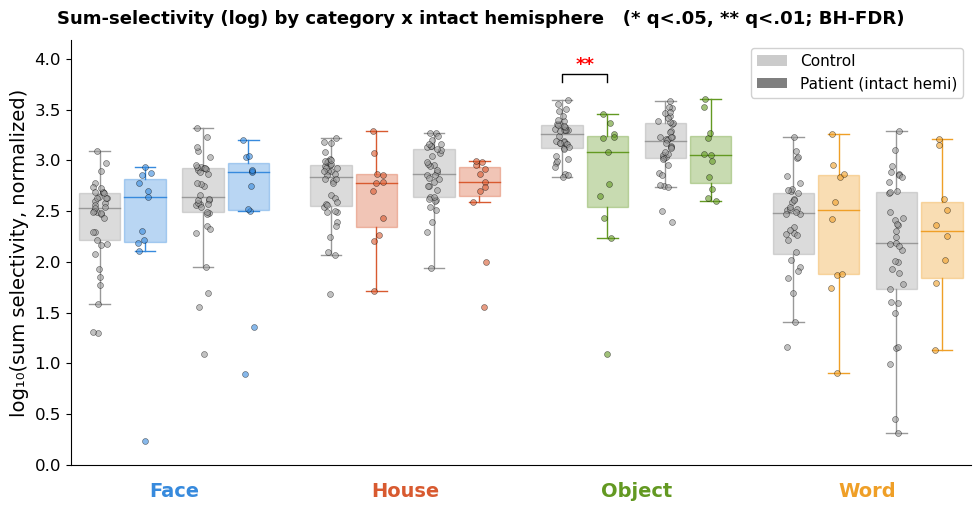

In [68]:
# Sum-selectivity box-whisker by category x intact hemi; q from stats_results.csv
CAT_PRIMARY = {'face': 'face_FFA', 'house': 'house_PPA',
               'object': 'object_LOC', 'word': 'word_VWFA'}
CAT_COLORS_SS = {'face': '#378ADD', 'house': '#D85A30',
                 'object': '#639922', 'word': '#EF9F27'}
CTRL_COLOR = '#999999'

def collapse_log_sumsel(df, subject, category, hemi):
    sub = df[(df['subject_id'] == subject) & (df['category'] == CAT_PRIMARY[category]) &
             (df['hemi'] == hemi)].drop_duplicates(subset=['subject_id', 'category', 'hemi'])
    vals = sub['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_PRIMARY:
            for h in ('l', 'r'):
                v = collapse_log_sumsel(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_ss = build_table(ctrl_le, ctrl_subs)
pt_ss   = build_table(pt_le,   otc_subs)
intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_ss['intact_hemi'] = pt_ss['subject_id'].map(intact_lookup)
pt_ss = pt_ss[
    ((pt_ss['intact_hemi'] == 'left')  & (pt_ss['hemi'] == 'l')) |
    ((pt_ss['intact_hemi'] == 'right') & (pt_ss['hemi'] == 'r'))
]

# q_fdr from authoritative stats (full LMM omnibus + per-ROI posthoc framework)
STATS_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results.csv')
_stats = pd.read_csv(STATS_CSV)
def q_lookup(cat, h):
    m = _stats[(_stats['measure'] == 'sum_selectivity') &
               (_stats['comparison'] == 'patient_vs_control') &
               (_stats['level'] == CAT_PRIMARY[cat]) & (_stats['hemi'] == h)]
    return float(m['q_fdr'].iloc[0]) if len(m) else np.nan
def _stars(q):
    if np.isnan(q): return ''
    if q < .001: return '***'
    if q < .01:  return '**'
    if q < .05:  return '*'
    return ''

CATS_PANEL = ['face', 'house', 'object', 'word']
INTRA, INTER, CAT_GAP = 0.55, 0.7, 1.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(10, 5))
RNG = np.random.RandomState(42)
cat_centers = []
all_vals = np.concatenate([ctrl_ss['val'].dropna().values, pt_ss['val'].dropna().values])
gmax, gmin = np.nanmax(all_vals), np.nanmin(all_vals)
brack_h = (gmax - gmin) * 0.02

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS_SS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))
    cl = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'l')]['val'].values
    cr = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'r')]['val'].values
    pl = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'l')]['val'].values
    pr = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'r')]['val'].values
    groups = [(cl, positions[0], CTRL_COLOR), (pl, positions[1], cat_color),
              (cr, positions[2], CTRL_COLOR), (pr, positions[3], cat_color)]
    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            bp = ax.boxplot([vals], positions=[pos], widths=0.5, patch_artist=True,
                            showfliers=False, manage_ticks=False, zorder=2)
            for box in bp['boxes']:
                box.set_facecolor(col); box.set_alpha(0.35); box.set_edgecolor(col)
            for el in ('whiskers', 'caps', 'medians'):
                for ln in bp[el]:
                    ln.set_color(col)
        jit = RNG.uniform(-0.09, 0.09, len(vals))
        #ax.scatter(np.full(len(vals), pos) + jit, vals, color=col, alpha=0.6,
        #           s=18, edgecolors='none', zorder=3)
        ax.scatter(np.full(len(vals), pos) + jit, vals, facecolors=col, alpha=0.6,
                   s=18, edgecolors='black', linewidths=0.4, zorder=3)
    for (h, x_l, x_r) in [('l', positions[0], positions[1]), ('r', positions[2], positions[3])]:
        stars = _stars(q_lookup(cat, h))
        if not stars: continue
        by = gmax + brack_h * 2
        ax.plot([x_l, x_l, x_r, x_r], [by, by + brack_h, by + brack_h, by],
                color='black', lw=1, zorder=6)
        ax.text((x_l + x_r) / 2, by + brack_h, stars, ha='center', va='bottom',
                color='red', fontsize=13, fontweight='bold', zorder=6)

ax.set_xticks([])
ax.set_ylabel('log₁₀(sum selectivity, normalized)', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
#ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())
total_width = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
ax.set_xlim(-0.35, total_width + 0.35); ax.margins(x=0.005)
yrange = gmax - gmin
#ax.set_ylim(gmin - 0.04 * yrange, gmax + 0.14 * yrange)
ax.set_ylim(0.0, gmax + 0.14*yrange)
ax.legend(handles=[Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control'),
                   Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi)')],
          loc='upper right', fontsize=11, frameon=True, framealpha=0.9)
plt.suptitle('Sum-selectivity (log) by category x intact hemisphere   '
             '(* q<.05, ** q<.01; BH-FDR)', fontsize=13, fontweight='bold', y=0.99)
plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
plt.savefig(FIG_DIR / 'liu_exact_sum_selectivity.png', dpi=300, bbox_inches='tight')
plt.show()

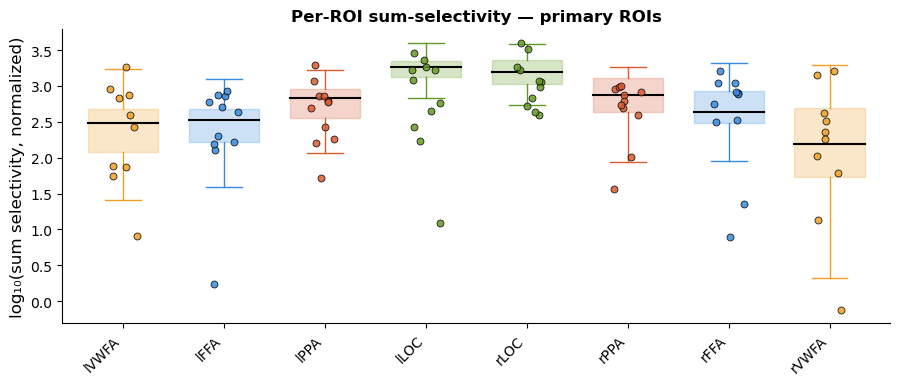

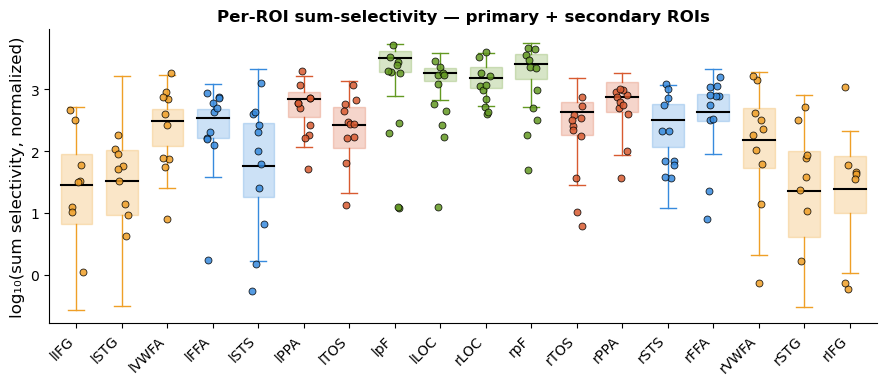

In [51]:
# Fig 3D style — SUM-SELECTIVITY by ROI (controls box + patient points): primary, then +secondary
ROI_ORDER_SECONDARY = [
    ('word_IFG',  'l'), ('word_STG',  'l'), ('word_VWFA', 'l'),
    ('face_FFA',  'l'), ('face_STS',  'l'),
    ('house_PPA', 'l'), ('house_TOS', 'l'),
    ('object_pF', 'l'), ('object_LOC','l'),
    ('object_LOC','r'), ('object_pF', 'r'),
    ('house_TOS', 'r'), ('house_PPA', 'r'),
    ('face_STS',  'r'), ('face_FFA',  'r'),
    ('word_VWFA', 'r'), ('word_STG',  'r'), ('word_IFG',  'r'),
]
ROI_ORDER_PRIMARY = [
    ('word_VWFA', 'l'), ('face_FFA', 'l'), ('house_PPA', 'l'), ('object_LOC', 'l'),
    ('object_LOC','r'), ('house_PPA','r'), ('face_FFA', 'r'), ('word_VWFA', 'r'),
]
ROI_CAT_COLOR = {
    'face_FFA':  '#378ADD', 'face_STS':  '#378ADD',
    'house_PPA': '#D85A30', 'house_TOS': '#D85A30',
    'object_pF': '#639922', 'object_LOC':'#639922',
    'word_VWFA': '#EF9F27', 'word_STG':  '#EF9F27', 'word_IFG': '#EF9F27',
}

_intact = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
def pt_intact_hemi(sub):
    h = _intact.get(sub)
    return None if h is None else ('l' if h == 'left' else 'r')

def roi_label(roi, hspec):
    return f"{hspec}{roi.split('_')[-1]}"

def get_sumsel(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    v = m['sum_selec_norm'].dropna().values
    v = v[v > 0]
    return np.log10(v[0]) if len(v) else np.nan

def ctrl_sumsel(roi, hspec):
    v = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == hspec)]['sum_selec_norm'].dropna().values
    v = v[v > 0]
    return np.log10(v) if len(v) else np.array([])

def plot_sumsel(roi_order, fname, title):
    n = len(roi_order)
    fig, ax = plt.subplots(figsize=(max(9, n * 0.42), 4.2))
    rng_d = np.random.RandomState(42)
    JITTER = 0.15
    for xi, (roi, hspec) in enumerate(roi_order):
        color = ROI_CAT_COLOR[roi]
        cvals = ctrl_sumsel(roi, hspec)
        if len(cvals) == 0: continue
        ax.boxplot(cvals, positions=[xi], widths=0.7, patch_artist=True,
                   showfliers=False, manage_ticks=False,
                   medianprops={'color': 'black', 'lw': 1.5},
                   whiskerprops={'color': color}, capprops={'color': color},
                   boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})
        for sub in otc_subs:
            pt_h = pt_intact_hemi(sub)
            if pt_h != hspec: continue
            val = get_sumsel(pt_le, sub, roi, pt_h)
            if np.isnan(val): continue
            ax.scatter(xi + rng_d.uniform(-JITTER, JITTER), val,
                       marker='o', s=25, zorder=5, edgecolors='black',
                       linewidth=0.6, facecolors=color, alpha=0.85)
    ax.set_xticks(np.arange(n))
    ax.set_xticklabels([roi_label(c, h) for c, h in roi_order],
                       rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('log₁₀(sum selectivity, normalized)', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-0.6, n - 0.4)
    ax.margins(x=0.005)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.subplots_adjust(left=0.07, right=0.99, top=0.92, bottom=0.22)
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_sumsel(ROI_ORDER_PRIMARY,   'liu_exact_sumsel_byroi_primary.png',
            'Per-ROI sum-selectivity — primary ROIs')
plot_sumsel(ROI_ORDER_SECONDARY, 'liu_exact_sumsel_byroi_secondary.png',
            'Per-ROI sum-selectivity — primary + secondary ROIs')

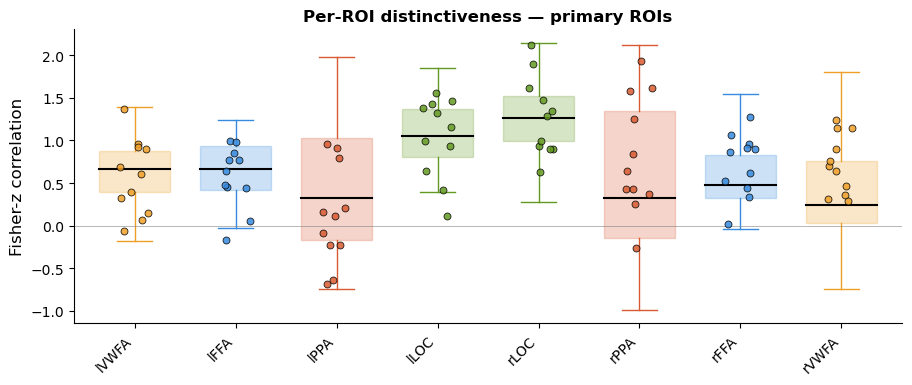

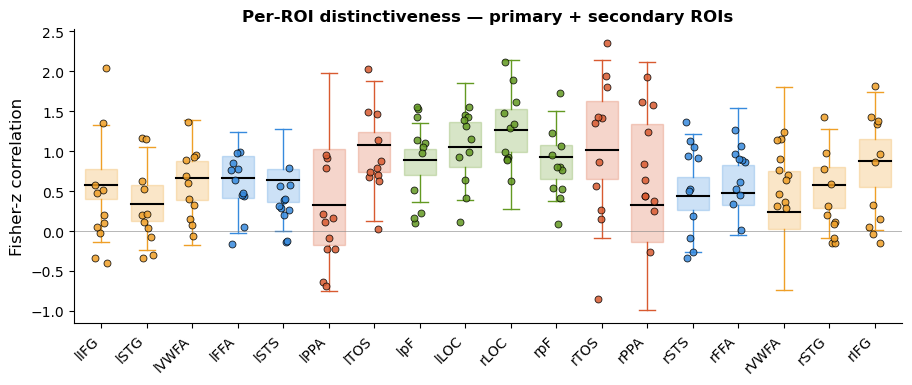

In [50]:
# Fig 3D — distinctiveness by ROI (controls box + patient points): primary, then +secondary
ROI_ORDER_SECONDARY = [
    ('word_IFG',  'l'), ('word_STG',  'l'), ('word_VWFA', 'l'),
    ('face_FFA',  'l'), ('face_STS',  'l'),
    ('house_PPA', 'l'), ('house_TOS', 'l'),
    ('object_pF', 'l'), ('object_LOC','l'),
    ('object_LOC','r'), ('object_pF', 'r'),
    ('house_TOS', 'r'), ('house_PPA', 'r'),
    ('face_STS',  'r'), ('face_FFA',  'r'),
    ('word_VWFA', 'r'), ('word_STG',  'r'), ('word_IFG',  'r'),
]
ROI_ORDER_PRIMARY = [
    ('word_VWFA', 'l'), ('face_FFA', 'l'), ('house_PPA', 'l'), ('object_LOC', 'l'),
    ('object_LOC','r'), ('house_PPA','r'), ('face_FFA', 'r'), ('word_VWFA', 'r'),
]
ROI_CAT_COLOR = {
    'face_FFA':  '#378ADD', 'face_STS':  '#378ADD',
    'house_PPA': '#D85A30', 'house_TOS': '#D85A30',
    'object_pF': '#639922', 'object_LOC':'#639922',
    'word_VWFA': '#EF9F27', 'word_STG':  '#EF9F27', 'word_IFG': '#EF9F27',
}

_intact = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
def pt_intact_hemi(sub):
    h = _intact.get(sub)
    return None if h is None else ('l' if h == 'left' else 'r')

def roi_label(roi, hspec):
    return f"{hspec}{roi.split('_')[-1]}"

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    return m['liu_distinctiveness'].values[0] if len(m) else np.nan

def plot_distinct(roi_order, fname, title):
    n = len(roi_order)
    fig, ax = plt.subplots(figsize=(max(9, n * 0.42), 4.2))
    rng_d = np.random.RandomState(42)
    JITTER = 0.15
    for xi, (roi, hspec) in enumerate(roi_order):
        color = ROI_CAT_COLOR[roi]
        cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == hspec)] \
                    ['liu_distinctiveness'].dropna().values
        if len(cvals) == 0: continue
        ax.boxplot(cvals, positions=[xi], widths=0.7, patch_artist=True,
                   showfliers=False, manage_ticks=False,
                   medianprops={'color': 'black', 'lw': 1.5},
                   whiskerprops={'color': color}, capprops={'color': color},
                   boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})
        for sub in otc_subs:
            pt_h = pt_intact_hemi(sub)
            if pt_h != hspec: continue
            val = get_distinct(pt_le, sub, roi, pt_h)
            if np.isnan(val): continue
            ax.scatter(xi + rng_d.uniform(-JITTER, JITTER), val,
                       marker='o', s=25, zorder=5, edgecolors='black',
                       linewidth=0.6, facecolors=color, alpha=0.85)
    ax.set_xticks(np.arange(n))
    ax.set_xticklabels([roi_label(c, h) for c, h in roi_order],
                       rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Fisher-z correlation', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-0.6, n - 0.4)
    ax.margins(x=0.005)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.subplots_adjust(left=0.07, right=0.99, top=0.92, bottom=0.22)
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_distinct(ROI_ORDER_PRIMARY,   'liu_exact_fig3D_primary.png',
              'Per-ROI distinctiveness — primary ROIs')
plot_distinct(ROI_ORDER_SECONDARY, 'liu_exact_fig3D_secondary.png',
              'Per-ROI distinctiveness — primary + secondary ROIs')

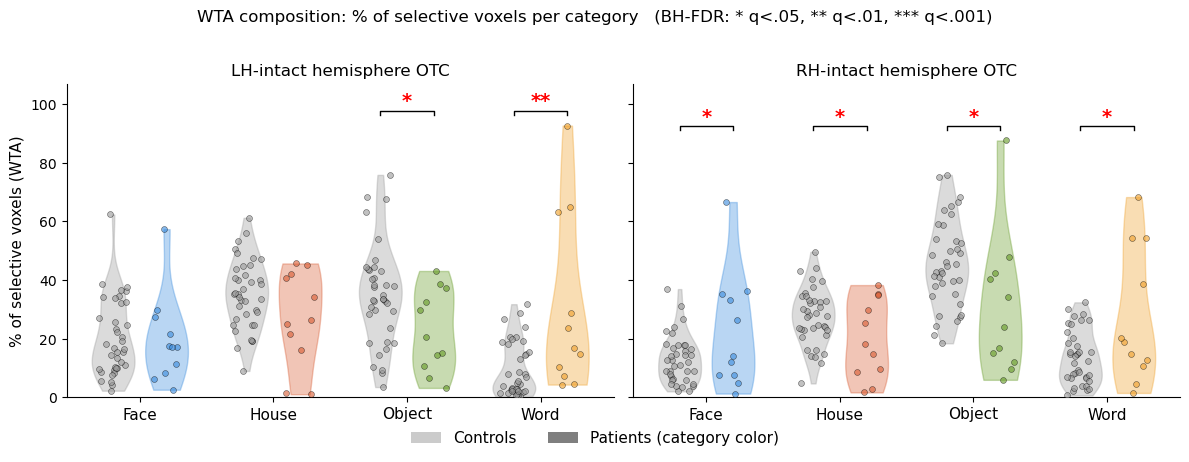

In [72]:
# WTA composition — violin/box toggle per category x group, LH-/RH-intact; q-stars from stats_results.csv
PLOT_KIND = 'violin'   # 'box' or 'violin'

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CTRL_COLOR = '#999999'
EXCLUDE = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
WTA_CSV   = '/user_data/csimmon2/sym_pt/group_results/wta_percentages.csv'
STATS_CSV = '/user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results.csv'
MODEL_FOR_HEMI = {'l': 'M1_LH_ctrl_vs_pt', 'r': 'M2_RH_ctrl_vs_pt'}

def _stars(q):
    if pd.isna(q): return ''
    if q < .001: return '***'
    if q < .01:  return '**'
    if q < .05:  return '*'
    return ''

def draw_dist(ax, vals, pos, col, width):
    if len(vals) < 2: return
    if PLOT_KIND == 'violin':
        parts = ax.violinplot([vals], positions=[pos], widths=width,
                              showmeans=False, showmedians=False, showextrema=False)
        for b in parts['bodies']:
            b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
    else:
        bp = ax.boxplot([vals], positions=[pos], widths=width, patch_artist=True,
                        showfliers=False, manage_ticks=False, zorder=2)
        for box in bp['boxes']:
            box.set_facecolor(col); box.set_alpha(0.35); box.set_edgecolor(col)
        for el in ('whiskers', 'caps', 'medians'):
            for ln in bp[el]:
                ln.set_color(col)

# load + session filter (controls first, OTC last) — matches 05
wta = pd.read_csv(WTA_CSV)
wta = wta[(wta['region'] == 'otc') & (wta['denominator'] == 'selective')].copy()
wta = wta[~wta['subject_id'].isin(EXCLUDE)]
wta['ses_num'] = pd.to_numeric(wta['session'], errors='coerce').astype('Int64')
for s, se in EXCLUDE_SES:
    wta = wta[~((wta['subject_id'] == s) & (wta['ses_num'] == se))]
_c = wta[wta['status'] == 'control']
_c = _c.merge(_c.groupby('subject_id')['ses_num'].min().rename('k').reset_index(), on='subject_id')
_c = _c[_c['ses_num'] == _c['k']].drop(columns='k')
_p = wta[wta['group'] == 'OTC']
_p = _p.merge(_p.groupby('subject_id')['ses_num'].max().rename('k').reset_index(), on='subject_id')
_p = _p[_p['ses_num'] == _p['k']].drop(columns='k')
wta = pd.concat([_c, _p], ignore_index=True)

# q's from stats_results (M1=LH, M2=RH)
stats = pd.read_csv(STATS_CSV)
sw = stats[(stats['measure'] == 'wta') & (stats['comparison'] == 'patient_vs_control')]
qmap = {}
for hemi, model in MODEL_FOR_HEMI.items():
    for _, r in sw[sw['model'] == model].iterrows():
        qmap[(hemi, r['level'])] = r['q_fdr']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(CATEGORIES))
w = 0.4
RNG = np.random.RandomState(0)

for ax, h, hlabel in zip(axes, ['l', 'r'], ['LH-intact', 'RH-intact']):
    sub = wta[wta['hemi'] == h]
    max_top = 0
    for offset, grp in [(-w/2, 'control'), (+w/2, 'OTC')]:
        for xi, c in enumerate(CATEGORIES):
            col = CTRL_COLOR if grp == 'control' else CAT_COLORS[c]
            pos = xi + offset
            vals = sub[(sub['category'] == c) & (sub['group'] == grp)]['wta_pct'].dropna().values
            draw_dist(ax, vals, pos, col, w*0.8)
            jit = (RNG.rand(len(vals)) - 0.5) * (w * 0.55)
            ax.scatter(pos + jit, vals, s=18, facecolors=col, alpha=0.6,
                       edgecolors='black', linewidths=0.4, zorder=3)
            if len(vals): max_top = max(max_top, vals.max())
    by, bh = max_top * 1.04, max_top * 0.015
    for xi, c in enumerate(CATEGORIES):
        s = _stars(qmap.get((h, c), np.nan))
        if not s: continue
        xl, xr = xi - w/2, xi + w/2
        ax.plot([xl, xl, xr, xr], [by, by+bh, by+bh, by], color='black', lw=1, zorder=4)
        ax.text(xi, by+bh, s, ha='center', va='bottom', color='red',
                fontsize=14, fontweight='bold', zorder=4)
    ax.set_ylim(0, max_top * 1.22)
    ax.set_xticks(x); ax.set_xticklabels([c.title() for c in CATEGORIES], fontsize=11)
    ax.set_title(f'{hlabel} hemisphere OTC', fontsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if h == 'l':
        ax.set_ylabel('% of selective voxels (WTA)', fontsize=11)

fig.legend(handles=[Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Controls'),
                    Patch(facecolor='black', alpha=0.5, label='Patients (category color)')],
           ncol=2, frameon=False, fontsize=11, loc='lower center', bbox_to_anchor=(0.5, -0.02))
fig.suptitle('WTA composition: % of selective voxels per category   '
             '(BH-FDR: * q<.05, ** q<.01, *** q<.001)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

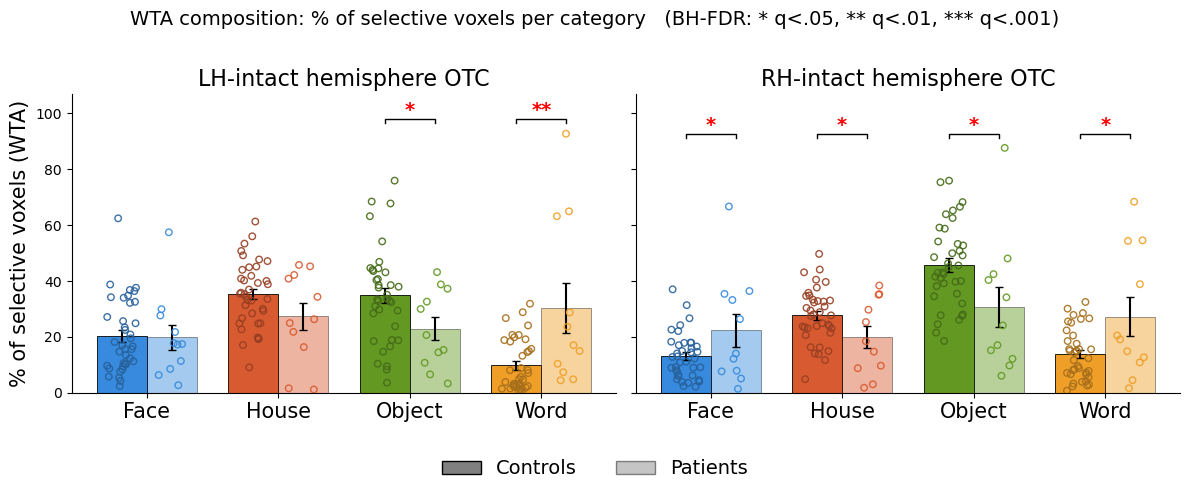

In [87]:
# WTA composition — bar plot (mean ± SEM) per category x group, LH-/RH-intact; q-stars from stats_results.csv
import matplotlib.colors as mcolors

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
EXCLUDE = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
WTA_CSV   = '/user_data/csimmon2/sym_pt/group_results/wta_percentages.csv'
STATS_CSV = '/user_data/csimmon2/git_repos/sym_pt/D_liu/stats_results.csv'
MODEL_FOR_HEMI = {'l': 'M1_LH_ctrl_vs_pt', 'r': 'M2_RH_ctrl_vs_pt'}

def darken(c, f=0.70):
    r, g, b = mcolors.to_rgb(c)
    return (r*f, g*f, b*f)

def _stars(q):
    if pd.isna(q): return ''
    if q < .001: return '***'
    if q < .01:  return '**'
    if q < .05:  return '*'
    return ''

# load + session filter (controls first, OTC last) — matches 05
wta = pd.read_csv(WTA_CSV)
wta = wta[(wta['region'] == 'otc') & (wta['denominator'] == 'selective')].copy()
wta = wta[~wta['subject_id'].isin(EXCLUDE)]
wta['ses_num'] = pd.to_numeric(wta['session'], errors='coerce').astype('Int64')
for s, se in EXCLUDE_SES:
    wta = wta[~((wta['subject_id'] == s) & (wta['ses_num'] == se))]
_c = wta[wta['status'] == 'control']
_c = _c.merge(_c.groupby('subject_id')['ses_num'].min().rename('k').reset_index(), on='subject_id')
_c = _c[_c['ses_num'] == _c['k']].drop(columns='k')
_p = wta[wta['group'] == 'OTC']
_p = _p.merge(_p.groupby('subject_id')['ses_num'].max().rename('k').reset_index(), on='subject_id')
_p = _p[_p['ses_num'] == _p['k']].drop(columns='k')
wta = pd.concat([_c, _p], ignore_index=True)

# q's from stats_results (M1=LH, M2=RH)
stats = pd.read_csv(STATS_CSV)
sw = stats[(stats['measure'] == 'wta') & (stats['comparison'] == 'patient_vs_control')]
qmap = {}
for hemi, model in MODEL_FOR_HEMI.items():
    for _, r in sw[sw['model'] == model].iterrows():
        qmap[(hemi, r['level'])] = r['q_fdr']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(CATEGORIES))
w = 0.38
RNG = np.random.RandomState(0)

for ax, h, hlabel in zip(axes, ['l', 'r'], ['LH-intact', 'RH-intact']):
    sub = wta[wta['hemi'] == h]
    max_top = 0
    for offset, grp, alpha in [(-w/2, 'control', 1.0), (+w/2, 'OTC', 0.45)]:
        means, sems = [], []
        for c in CATEGORIES:
            vals = sub[(sub['category'] == c) & (sub['group'] == grp)]['wta_pct']
            means.append(vals.mean()); sems.append(vals.sem())
        ax.bar(x + offset, means, w, yerr=sems,
               color=[CAT_COLORS[c] for c in CATEGORIES], alpha=alpha,
               edgecolor='black', linewidth=0.6, capsize=3, zorder=2)
        for xi, c in enumerate(CATEGORIES):
            vals = sub[(sub['category'] == c) & (sub['group'] == grp)]['wta_pct'].values
            ecol = darken(CAT_COLORS[c]) if grp == 'control' else CAT_COLORS[c]
            jit = (RNG.rand(len(vals)) - 0.5) * (w * 0.6)
            ax.scatter(xi + offset + jit, vals, s=22, facecolors='none',
                       edgecolors=ecol, linewidths=1.0, alpha=0.9, zorder=3)
            if len(vals): max_top = max(max_top, vals.max())
    by, bh = max_top * 1.04, max_top * 0.015
    for xi, c in enumerate(CATEGORIES):
        s = _stars(qmap.get((h, c), np.nan))
        if not s: continue
        xl, xr = xi - w/2, xi + w/2
        ax.plot([xl, xl, xr, xr], [by, by+bh, by+bh, by], color='black', lw=1, zorder=4)
        ax.text(xi, by+bh, s, ha='center', va='bottom', color='red',
                fontsize=14, fontweight='bold', zorder=4)
    ax.set_ylim(0, max_top * 1.22)
    ax.set_xticks(x); ax.set_xticklabels([c.title() for c in CATEGORIES], fontsize=15)
    ax.set_title(f'{hlabel} hemisphere OTC', fontsize=16)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if h == 'l':
        ax.set_ylabel('% of selective voxels (WTA)', fontsize=15)

fig.legend(handles=[Patch(facecolor='gray', edgecolor='black', label='Controls'),
                    Patch(facecolor='gray', alpha=0.45, edgecolor='black', label='Patients')],
           ncol=2, frameon=False, fontsize=14, loc='lower center', bbox_to_anchor=(0.5, -0.1))
fig.suptitle('WTA composition: % of selective voxels per category   '
             '(BH-FDR: * q<.05, ** q<.01, *** q<.001)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()